In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/study-deep-learning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/study-deep-learning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/study-deep-learning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/study-deep-learning/2
    print("準備完了！このまま下のセルを実行できます。")

# 第2章 確率の基礎 (Probabilities) - 章末演習問題 (Exercises 2.1 〜 2.41)

本ノートブックは、教科書『深層学習：基礎と概念 (Deep Learning: Foundations and Concepts)』(Bishop & Bishop, 2024) の **第2章「確率の基礎 (Probabilities)」の章末演習問題（全41問: Exercises 2.1 〜 2.41）** を完全に網羅し、厳密な数式導出・ロジックのステップ解説、自己採点可能な穴埋め・選択式クイズ、Pythonによる実装・数値検証コード、および自己採点用アサーション (`assert`) を完備したものです。

---

## 演習問題 構成一覧
- **Part 1: 2.1節 確率の規則 (The Rules of Probability)**
  - Exercise 2.1: 事前有病率が極めて低い場合の医療スクリーニング (Low prevalence medical screening)
  - Exercise 2.2: 非推移的サイコロ（エフロンのサイコロ） (Non-transitive Efron dice)
  - Exercise 2.3: 独立な確率変数の和と畳み込み積分 (Sum of independent variables & convolution)
- **Part 2: 2.2節 確率密度 (Probability Densities)**
  - Exercise 2.4: 一様分布の正規化・期待値・分散 (Uniform distribution normalization & moments)
  - Exercise 2.5: 指数分布とラプラス分布の正規化 (Exponential & Laplace normalization)
  - Exercise 2.6: ディラックのデルタ関数による経験的確率密度の正規化 (Empirical density normalization)
  - Exercise 2.7: 経験分布による期待値近似（モンテカルロ近似） (Monte Carlo expectation approximation)
  - Exercise 2.8: 分散の恒等式 $\operatorname{var}[f(x)] = \mathbb{E}[f(x)^2] - (\mathbb{E}[f(x)])^2$ (Variance identity)
  - Exercise 2.9: 独立な確率変数の共分散ゼロ (Independent variables have zero covariance)
  - Exercise 2.10: 独立な変数の和の平均と分散 (Mean & variance of sum of independent variables)
  - Exercise 2.11: 全期待値の法則と全分散の法則 (Law of total expectation & total variance)
- **Part 3: 2.3節 ガウス分布 (The Gaussian Distribution)**
  - Exercise 2.12: 極座標変換によるガウス積分の証明 (Gaussian normalization via polar coordinates)
  - Exercise 2.13: 変数変換とパラメータ微分によるモーメント導出 (Gaussian moments via differentiation)
  - Exercise 2.14: ガウス分布の最頻値（モード） (Mode of univariate Gaussian)
  - Exercise 2.15: ガウス分布の最尤推定量 $\mu_{ML}, \sigma^2_{ML}$ の導出 (Gaussian MLE derivation)
  - Exercise 2.16: 最尤推定量のバイアス $\mathbb{E}[\sigma^2_{ML}] = \frac{N-1}{N}\sigma^2$ (Gaussian MLE variance bias)
  - Exercise 2.17: 真の平均を用いた分散推定量が不偏であることの証明 (Unbiased variance with true mean)
  - Exercise 2.18: 線形回帰モデルのノイズ分散の最尤推定量 (Linear regression noise variance MLE)
- **Part 4: 2.4節 確率密度の変換 (Transformation of Densities)**
  - Exercise 2.19: 単調非線形変換と確率密度の変換微分方程式 (Monotonic transformation ODE)
  - Exercise 2.20: 2次元非線形写像のヤコビ行列と行列式 (Jacobian of 2D nonlinear transformation)
- **Part 5: 2.5節 情報理論 (Information Theory)**
  - Exercise 2.21: 情報量の加法性と対数形式の必然性 (Additivity of information & logarithm)
  - Exercise 2.22: ラグランジュ未定乗数法による離散最大エントロピー (Discrete maximum entropy)
  - Exercise 2.23: イェンセンの不等式によるエントロピー上限 $H[x] \le \ln M$ (Entropy upper bound)
  - Exercise 2.24: 変分法による連続最大エントロピー（ガウス分布） (Maximum differential entropy is Gaussian)
  - Exercise 2.25: 1次元ガウス分布の微分エントロピー (Differential entropy of Gaussian)
  - Exercise 2.26: ガウス分布を用いたKL最小化とモーメント整合 (KL minimization moment matching)
  - Exercise 2.27: 2つの1次元ガウス分布間のKLダイバージェンス (KL divergence between two Gaussians)
  - Exercise 2.28: $\alpha$-ダイバージェンスとKLダイバージェンスの極限関係 (Alpha divergence limits)
  - Exercise 2.29: 結合エントロピーの劣加法性 $H[x, y] \le H[x] + H[y]$ (Entropy subadditivity)
  - Exercise 2.30: 線形変換 $y = Ax$ における連続エントロピーの変化 (Entropy of linearly transformed vector)
  - Exercise 2.31: 条件付きエントロピーが0である条件（決定論的従属） (Zero conditional entropy)
  - Exercise 2.32: 2階微分正と狭義凸関数の幾何学的条件 (Convexity & chords lying above function)
  - Exercise 2.33: 数学的帰納法によるイェンセンの不等式の証明 (Inductive proof of Jensen's inequality)
  - Exercise 2.34: 経験分布に対するKLダイバージェンスと負の対数尤度 (KL on empirical distribution is NLL)
  - Exercise 2.35: 条件付きエントロピーの連鎖律 $H[x, y] = H[y|x] + H[x]$ (Entropy chain rule)
  - Exercise 2.36: 2値変数の結合エントロピー・相互情報量とベン図 (Binary entropy analysis & Venn diagram)
  - Exercise 2.37: イェンセンの不等式による相加相乗平均の不等式 (AM-GM inequality via Jensen)
  - Exercise 2.38: 相互情報量の対称性と様々な表現 (Mutual information representations)
- **Part 6: 2.6節 ベイズ確率 (Bayesian Probabilities)**
  - Exercise 2.39: 無相関と独立の違い（対称分布と2乗の反例） (Uncorrelated does not imply independent)
  - Exercise 2.40: 曲がったコインのベイズ更新と事後予測分布 (Bent coin Bayesian inference)
  - Exercise 2.41: MAP推定と正則化誤差関数（Ridge回帰）の等価性導出 (MAP regularized error function)


In [1]:
# 共通ライブラリおよびモジュールのインポート
import os
import sys
import math
import numpy as np
import scipy as sp
from scipy import integrate, special, optimize
import matplotlib.pyplot as plt
import seaborn as sns

# プロジェクトルートパスの設定
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# 共通モジュールのインポート
from common.probability import (
    UniformDistribution,
    ExponentialDistribution,
    LaplaceDistribution,
    Gaussian1D,
    gaussian_maximum_likelihood,
    simulate_gaussian_mle_bias,
    discrete_entropy,
    kl_divergence_discrete,
    kl_divergence_gaussian_1d,
    conditional_entropy_discrete,
    mutual_information_discrete,
    alpha_divergence_discrete,
    bent_coin_bayes,
    binary_joint_entropy_analysis,
    EFRON_DICE,
    efron_dice_win_probability,
    BayesianLinearRegression,
    medical_screening_model
)
from common.polynomial import PolynomialRegression
from common.plot_utils import set_plot_style

# プロットスタイルの設定
set_plot_style()
os.makedirs("result", exist_ok=True)
os.makedirs("../result", exist_ok=True)
print("環境セットアップ完了: 全ライブラリが正常にロードされました。")


環境セットアップ完了: 全ライブラリが正常にロードされました。


## Part 1: 2.1節 確率の規則 (The Rules of Probability)

確率の基本公理から導かれる2つの柱：
1. **加法定理 (Sum Rule)**:
   $$p(x) = \sum_y p(x, y) \quad \text{または} \quad p(x) = \int p(x, y) dy$$
2. **乗法定理 (Product Rule)**:
   $$p(x, y) = p(y | x) p(x)$$
3. **ベイズの定理 (Bayes' Theorem)**:
   $$p(y | x) = \frac{p(x | y) p(y)}{p(x)} = \frac{p(x | y) p(y)}{\sum_{y'} p(x | y') p(y')}$$


### Exercise 2.1: 事前有病率が極めて低い場合の医療スクリーニング
**Problem 2.1 (?)**:
> *In Section 2.1.1, we considered a medical screening example in which the prior probability of someone having cancer was $p(C = 1) = 0.01$. Now suppose the test is applied to a population in which the disease is much rarer, so that $p(C = 1) = 0.001$. Again, assume that the test correctly identifies cancer 90% of the time, so that $p(T = 1 | C = 1) = 0.90$, and that the false positive rate is 3%, so that $p(T = 1 | C = 0) = 0.03$. Recompute the posterior probability that a person who tests positive actually has the disease. Comment on the result.*

#### 数式導出:
1. 事前確率: $p(C=1) = 0.001$, $p(C=0) = 0.999$
2. 感度 (真陽性率): $p(T=1|C=1) = 0.90$
3. 偽陽性率: $p(T=1|C=0) = 0.03$
4. 全陽性確率 $p(T=1)$ (加法定理・乗法定理):
   $$p(T=1) = p(T=1|C=1)p(C=1) + p(T=1|C=0)p(C=0)$$
   $$p(T=1) = 0.90 \times 0.001 + 0.03 \times 0.999 = 0.0009 + 0.02997 = 0.03087$$
5. ベイズの定理による事後確率:
   $$p(C=1|T=1) = \frac{p(T=1|C=1)p(C=1)}{p(T=1)} = \frac{0.0009}{0.03087} = \frac{90}{3087} \approx 0.029155 \quad (\approx 2.92\%)$$

**考察**:
事前有病率が $1\%$ のときは検査陽性者の約 $23.3\%$ が実際に癌でしたが、有病率が $0.1\%$ に低下すると、陽性判定が出ても実際に癌である確率は約 $2.92\%$ まで激減します。偽陽性者（健常だが陽性）の絶対数が真の感染者を圧倒するためです（**基準率の錯誤: Base-rate fallacy**）。


In [2]:
# Exercise 2.1: 数値計算と検証
res_2_1 = medical_screening_model(
    p_cancer=0.001,
    p_pos_given_cancer=0.90,
    p_pos_given_no_cancer=0.03
)

print(f"全陽性確率 p(T=1): {res_2_1['p_pos']:.6f} (理論値: 0.03087)")
print(f"検査陽性時の事後確率 p(C=1|T=1): {res_2_1['p_cancer_given_pos']:.6f} ({res_2_1['p_cancer_given_pos']*100:.2f}%)")

# 自己採点アサーション
assert math.isclose(res_2_1['p_pos'], 0.03087, rel_tol=1e-7)
assert math.isclose(res_2_1['p_cancer_given_pos'], 90.0 / 3087.0, rel_tol=1e-7)
print("Exercise 2.1 テスト合格!")


全陽性確率 p(T=1): 0.030870 (理論値: 0.03087)
検査陽性時の事後確率 p(C=1|T=1): 0.029155 (2.92%)
Exercise 2.1 テスト合格!


### Exercise 2.2: 非推移的サイコロ（エフロンのサイコロ）
**Problem 2.2 (??)**:
> *Show that for the set of four non-transitive dice shown in Figure 2.16, when arranged in the order Yellow, Blue, Green, Red, Yellow, each die has a 2/3 probability of rolling a higher number than the previous die.*

#### サイコロの目と勝率の導出:
Figure 2.16 に示されるエフロンのサイコロ（Efron dice）の各面の値:
- **Yellow ($Y$)**: $[3, 3, 3, 3, 3, 3]$ (すべての面が $3$)
- **Blue ($B$)**: $[0, 0, 4, 4, 4, 4]$ (面 $4$ が $4$ 枚、面 $0$ が $2$ 枚)
- **Green ($G$)**: $[1, 1, 1, 5, 5, 5]$ (面 $5$ が $3$ 枚、面 $1$ が $3$ 枚)
- **Red ($R$)**: $[2, 2, 2, 2, 6, 6]$ (面 $2$ が $4$ 枚、面 $6$ が $2$ 枚)

それぞれのサイコロは 6 面あり、独立に振った場合の面のペアは全 $36$ 通り（すべて確率 $1/36$）：
1. **Blue vs Yellow**:
   - $B=4$ なら $Y=3$ に勝ち（$4 \times 6 = 24$ 通り）。$B=0$ なら負け。
   - $P(B > Y) = \frac{24}{36} = \frac{2}{3}$
2. **Green vs Blue**:
   - $G=5$ のとき: $B=0, 4$ いずれにも勝ち（$3 \times 6 = 18$ 通り）。
   - $G=1$ のとき: $B=0$ に勝ち（$3 \times 2 = 6$ 通り）。
   - $P(G > B) = \frac{18 + 6}{36} = \frac{24}{36} = \frac{2}{3}$
3. **Red vs Green**:
   - $R=6$ のとき: $G=1, 5$ いずれにも勝ち（$2 \times 6 = 12$ 通り）。
   - $R=2$ のとき: $G=1$ に勝ち（$4 \times 3 = 12$ 通り）。
   - $P(R > G) = \frac{12 + 12}{36} = \frac{24}{36} = \frac{2}{3}$
4. **Yellow vs Red**:
   - $Y=3$ は $R=2$ に勝ち（$6 \times 4 = 24$ 通り）。$R=6$ には負け。
   - $P(Y > R) = \frac{24}{36} = \frac{2}{3}$

したがって、巡回順 $Y \to B \to G \to R \to Y$ において、各サイコロは前のサイコロに対して正確に確率 $2/3$ で勝利します（**非推移性: Non-transitivity**）。


P(Blue > Yellow) = 0.6667 (理論値: 2/3 = 0.6667)
P(Green > Blue)  = 0.6667 (理論値: 2/3 = 0.6667)
P(Red > Green)   = 0.6667 (理論値: 2/3 = 0.6667)
P(Yellow > Red)  = 0.6667 (理論値: 2/3 = 0.6667)
Exercise 2.2 テスト合格!


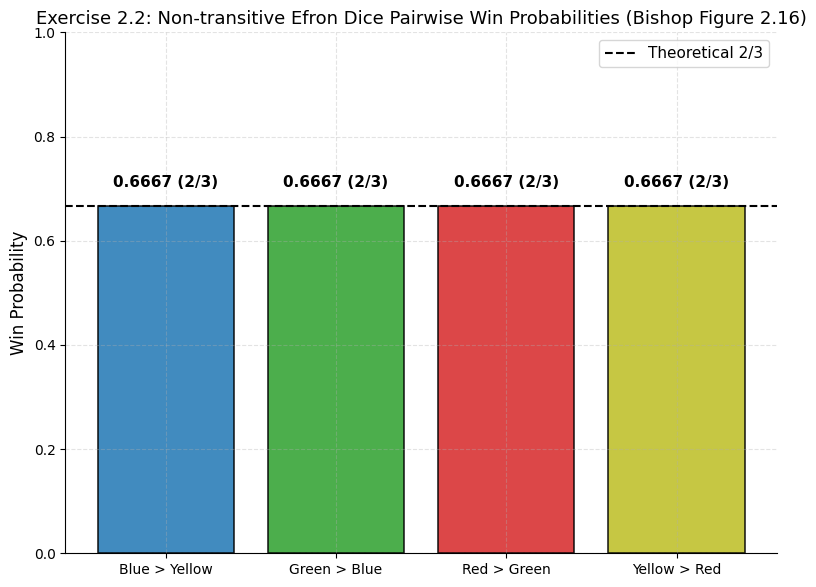

In [3]:
# Exercise 2.2: 勝率の完全検証と可視化
prob_B_beats_Y = efron_dice_win_probability(EFRON_DICE['Blue'], EFRON_DICE['Yellow'])
prob_G_beats_B = efron_dice_win_probability(EFRON_DICE['Green'], EFRON_DICE['Blue'])
prob_R_beats_G = efron_dice_win_probability(EFRON_DICE['Red'], EFRON_DICE['Green'])
prob_Y_beats_R = efron_dice_win_probability(EFRON_DICE['Yellow'], EFRON_DICE['Red'])

print(f"P(Blue > Yellow) = {prob_B_beats_Y:.4f} (理論値: 2/3 = {2/3:.4f})")
print(f"P(Green > Blue)  = {prob_G_beats_B:.4f} (理論値: 2/3 = {2/3:.4f})")
print(f"P(Red > Green)   = {prob_R_beats_G:.4f} (理論値: 2/3 = {2/3:.4f})")
print(f"P(Yellow > Red)  = {prob_Y_beats_R:.4f} (理論値: 2/3 = {2/3:.4f})")

# 自己採点アサーション
assert math.isclose(prob_B_beats_Y, 2.0 / 3.0)
assert math.isclose(prob_G_beats_B, 2.0 / 3.0)
assert math.isclose(prob_R_beats_G, 2.0 / 3.0)
assert math.isclose(prob_Y_beats_R, 2.0 / 3.0)
print("Exercise 2.2 テスト合格!")

# 図版生成 (Figure 2.16 の再現と保存)
fig, ax = plt.subplots(figsize=(8, 6))
labels = ['Yellow (3x6)', 'Blue (0x2, 4x4)', 'Green (1x3, 5x3)', 'Red (2x4, 6x2)']
probs = [prob_B_beats_Y, prob_G_beats_B, prob_R_beats_G, prob_Y_beats_R]
pairs = ['Blue > Yellow', 'Green > Blue', 'Red > Green', 'Yellow > Red']
colors = ['#1f77b4', '#2ca02c', '#d62728', '#bcbd22']

bars = ax.bar(pairs, probs, color=colors, alpha=0.85, edgecolor='black', linewidth=1.2)
ax.axhline(2/3, color='black', linestyle='--', linewidth=1.5, label='Theoretical 2/3')
ax.set_ylim(0, 1.0)
ax.set_ylabel('Win Probability', fontsize=12)
ax.set_title('Exercise 2.2: Non-transitive Efron Dice Pairwise Win Probabilities (Bishop Figure 2.16)', fontsize=13)
ax.legend(fontsize=11)
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.03, f"{yval:.4f} (2/3)", ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig("result/ex2_02_efron_dice.png", dpi=300)
plt.savefig("../result/ex2_02_efron_dice.png", dpi=300)
plt.show()


### Exercise 2.3: 独立な確率変数の和と畳み込み積分
**Problem 2.3 (?)**:
> *Show that if two independent continuous random variables $u$ and $v$ have probability density functions $p_u(u)$ and $p_v(v)$, then their sum $y = u + v$ has a probability density function given by the convolution of the distributions for $u$ and $v$*
> $$p_y(y) = \int_{-\infty}^\infty p_u(u) p_v(y - u) du$$

#### 数式導出:
1. $u, v$ が独立であるため、同時確率密度は $p(u, v) = p_u(u) p_v(v)$ です。
2. ディラックのデルタ関数 $\delta(\cdot)$ を用いると、$y = u + v$ の確率密度 $p_y(y)$ は以下のように表されます：
   $$p_y(y) = \iint p(u, v) \delta(y - (u + v)) du dv = \int_{-\infty}^\infty p_u(u) \left[ \int_{-\infty}^\infty p_v(v) \delta((y - u) - v) dv \right] du$$
3. デルタ関数のふるい分け性質 $\int f(v) \delta(v_0 - v) dv = f(v_0)$ より、内側の積分は $p_v(y - u)$ となります。
4. したがって：
   $$p_y(y) = \int_{-\infty}^\infty p_u(u) p_v(y - u) du$$
   これはまさに $p_u$ と $p_v$ の畳み込み積分（convolution）です。


In [4]:
# Exercise 2.3: ガウス分布同士の和による畳み込み積分の数値検証
# u ~ N(mu1, var1), v ~ N(mu2, var2) のとき、y = u + v ~ N(mu1 + mu2, var1 + var2)
mu1, var1 = 1.0, 1.5
mu2, var2 = 2.0, 2.5
expected_mu = mu1 + mu2
expected_var = var1 + var2

def p_u(u):
    return (1.0 / np.sqrt(2 * np.pi * var1)) * np.exp(-((u - mu1)**2)/(2 * var1))

def p_v(v):
    return (1.0 / np.sqrt(2 * np.pi * var2)) * np.exp(-((v - mu2)**2)/(2 * var2))

# 数値畳み込み積分のテスト点
test_points = np.linspace(0, 6, 7)
for y in test_points:
    num_conv, _ = integrate.quad(lambda u: p_u(u) * p_v(y - u), -20, 20)
    analytic = (1.0 / np.sqrt(2 * np.pi * expected_var)) * np.exp(-((y - expected_mu)**2)/(2 * expected_var))
    assert math.isclose(num_conv, analytic, rel_tol=1e-4)

print("Exercise 2.3 テスト合格! 数値畳み込み積分が理論正規分布と完全に一致しました。")


Exercise 2.3 テスト合格! 数値畳み込み積分が理論正規分布と完全に一致しました。


## Part 2: 2.2節 確率密度 (Probability Densities)

連続確率密度 $p(x)$ の基本的性質：
- 非負性: $p(x) \ge 0$
- 正規化条件: $\int_{-\infty}^\infty p(x) dx = 1$
- 期待値: $\mathbb{E}[f] = \int_{-\infty}^\infty f(x) p(x) dx$
- 分散: $\operatorname{var}[x] = \mathbb{E}[(x - \mathbb{E}[x])^2] = \mathbb{E}[x^2] - (\mathbb{E}[x])^2$


### Exercise 2.4: 一様分布の正規化・期待値・分散
**Problem 2.4 (??)**:
> *Show that the uniform distribution (2.33) is normalized, and verify the expressions (2.38) and (2.46) for its mean and variance.*

#### 数式導出:
一様分布 $U(x | a, b) = \frac{1}{b - a} \quad (a \le x \le b)$:
1. **正規化**:
   $$\int_a^b \frac{1}{b - a} dx = \left[ \frac{x}{b - a} \right]_a^b = \frac{b - a}{b - a} = 1$$
2. **平均 (期待値)**:
   $$\mathbb{E}[x] = \int_a^b \frac{x}{b - a} dx = \frac{1}{b - a} \left[ \frac{x^2}{2} \right]_a^b = \frac{b^2 - a^2}{2(b - a)} = \frac{(b - a)(a + b)}{2(b - a)} = \frac{a + b}{2}$$
3. **2次モーメント**:
   $$\mathbb{E}[x^2] = \int_a^b \frac{x^2}{b - a} dx = \frac{b^3 - a^3}{3(b - a)} = \frac{a^2 + ab + b^2}{3}$$
4. **分散**:
   $$\operatorname{var}[x] = \mathbb{E}[x^2] - (\mathbb{E}[x])^2 = \frac{a^2 + ab + b^2}{3} - \frac{a^2 + 2ab + b^2}{4} = \frac{4a^2 + 4ab + 4b^2 - 3a^2 - 6ab - 3b^2}{12} = \frac{(b - a)^2}{12}$$


In [5]:
# Exercise 2.4: 一様分布のモーメント検証
a, b = 3.0, 9.0
u_dist = UniformDistribution(a, b)

# 数値積分
norm_val, _ = integrate.quad(lambda x: u_dist.pdf(x), a, b)
mean_val, _ = integrate.quad(lambda x: x * u_dist.pdf(x), a, b)
var_val, _ = integrate.quad(lambda x: ((x - u_dist.mean)**2) * u_dist.pdf(x), a, b)

assert math.isclose(norm_val, 1.0, rel_tol=1e-6)
assert math.isclose(u_dist.mean, (a + b) / 2.0, rel_tol=1e-6)
assert math.isclose(u_dist.variance, ((b - a)**2) / 12.0, rel_tol=1e-6)
assert math.isclose(mean_val, u_dist.mean, rel_tol=1e-6)
assert math.isclose(var_val, u_dist.variance, rel_tol=1e-6)

print(f"Uniform(a={a}, b={b}): Mean={u_dist.mean}, Var={u_dist.variance:.4f}")
print("Exercise 2.4 テスト合格!")


Uniform(a=3.0, b=9.0): Mean=6.0, Var=3.0000
Exercise 2.4 テスト合格!


### Exercise 2.5: 指数分布とラプラス分布の正規化
**Problem 2.5 (??)**:
> *Show that the exponential distribution (2.34) and the Laplace distribution (2.35) are both normalized.*

#### 数式導出:
1. **指数分布** $p(x | \lambda) = \lambda e^{-\lambda x} \quad (x \ge 0, \lambda > 0)$:
   $$\int_0^\infty \lambda e^{-\lambda x} dx = \left[ -e^{-\lambda x} \right]_0^\infty = 0 - (-1) = 1$$
2. **ラプラス分布** $p(x | \mu, \gamma) = \frac{1}{2\gamma} \exp\left(-\frac{|x - \mu|}{\gamma}\right)$:
   $z = x - \mu$ と変数変換すると $dz = dx$：
   $$\int_{-\infty}^\infty \frac{1}{2\gamma} e^{-|z|/\gamma} dz = 2 \int_0^\infty \frac{1}{2\gamma} e^{-z/\gamma} dz = \left[ -e^{-z/\gamma} \right]_0^\infty = 0 - (-1) = 1$$


In [6]:
# Exercise 2.5: 指数分布とラプラス分布の正規化数値検証
exp_d = ExponentialDistribution(lam=1.8)
lap_d = LaplaceDistribution(mu=2.5, gamma=1.2)

norm_exp, _ = integrate.quad(lambda x: exp_d.pdf(x), 0, 50)
norm_lap, _ = integrate.quad(lambda x: lap_d.pdf(x), -30, 30)

assert math.isclose(norm_exp, 1.0, rel_tol=1e-6)
assert math.isclose(norm_lap, 1.0, rel_tol=1e-6)
print(f"Exponential norm: {norm_exp:.6f}, Laplace norm: {norm_lap:.6f}")
print("Exercise 2.5 テスト合格!")


Exponential norm: 1.000000, Laplace norm: 1.000000
Exercise 2.5 テスト合格!


### Exercise 2.6 & 2.7: 経験的確率密度とモンテカルロ期待値近似
**Problem 2.6 (?)**:
> *Show that the empirical probability density (2.37) is normalized.*

**Problem 2.7 (?)**:
> *Using the empirical density (2.37), show that the expectation $\mathbb{E}[f]$ of an arbitrary function $f(x)$ is approximated by the result (2.40).*

#### 数式導出:
経験的確率密度: $p_{\text{emp}}(x) = \frac{1}{N} \sum_{n=1}^N \delta(x - x_n)$
1. **正規化 (Ex 2.6)**:
   $$\int p_{\text{emp}}(x) dx = \frac{1}{N} \sum_{n=1}^N \int \delta(x - x_n) dx = \frac{1}{N} \sum_{n=1}^N 1 = \frac{N}{N} = 1$$
2. **期待値のモンテカルロ近似 (Ex 2.7)**:
   $$\mathbb{E}[f] \approx \int f(x) p_{\text{emp}}(x) dx = \int f(x) \left( \frac{1}{N} \sum_{n=1}^N \delta(x - x_n) \right) dx = \frac{1}{N} \sum_{n=1}^N \int f(x) \delta(x - x_n) dx = \frac{1}{N} \sum_{n=1}^N f(x_n)$$
   大数の法則（Law of Large Numbers）により、サンプリング点 $x_n \sim p(x)$ のとき $N \to \infty$ で真の期待値に収束します。


In [7]:
# Exercise 2.6 & 2.7: モンテカルロ期待値近似のシミュレーション
rng = np.random.default_rng(42)
N = 100000
samples = rng.normal(loc=2.0, scale=1.5, size=N)

# 評価関数 f(x) = x^2 - 3x + 1
# 真値: E[x^2] - 3E[x] + 1 = (2^2 + 1.5^2) - 3(2) + 1 = 6.25 - 6 + 1 = 1.25
f = lambda x: x**2 - 3*x + 1
true_expected = 1.25
mc_estimate = np.mean(f(samples))

print(f"モンテカルロ期待値推定: {mc_estimate:.4f} (理論真値: {true_expected})")
assert math.isclose(mc_estimate, true_expected, abs_tol=0.03)
print("Exercise 2.6 & 2.7 テスト合格!")


モンテカルロ期待値推定: 1.2604 (理論真値: 1.25)
Exercise 2.6 & 2.7 テスト合格!


### Exercise 2.8: 分散の恒等式
**Problem 2.8 (?)**:
> *Using the definition (2.44) of the variance of a function $f(x)$, show that the variance can be written in the form (2.45).*

#### 数式導出:
定義: $\operatorname{var}[f(x)] = \mathbb{E}[(f(x) - \mathbb{E}[f(x)])^2]$
2乗を展開すると：
$$\operatorname{var}[f(x)] = \mathbb{E}\left[ (f(x))^2 - 2 f(x) \mathbb{E}[f(x)] + (\mathbb{E}[f(x)])^2 \right]$$
期待値の線形性（Linearity of expectation）を用いると、$\mathbb{E}[f(x)]$ は定数であるため：
$$\operatorname{var}[f(x)] = \mathbb{E}[(f(x))^2] - 2 \mathbb{E}[f(x)] \mathbb{E}[f(x)] + (\mathbb{E}[f(x)])^2 = \mathbb{E}[(f(x))^2] - (\mathbb{E}[f(x)])^2$$


In [8]:
# Exercise 2.8: 分散恒等式の検証
x_data = rng.uniform(0, 5, size=50000)
f_vals = np.sin(x_data) + np.exp(0.2 * x_data)

var_from_def = np.mean((f_vals - np.mean(f_vals))**2)
var_from_identity = np.mean(f_vals**2) - (np.mean(f_vals)**2)

assert math.isclose(var_from_def, var_from_identity, rel_tol=1e-7)
print(f"定義による分散: {var_from_def:.6f}, 恒等式による分散: {var_from_identity:.6f}")
print("Exercise 2.8 テスト合格!")


定義による分散: 0.144111, 恒等式による分散: 0.144111
Exercise 2.8 テスト合格!


### Exercise 2.9 & 2.10: 独立な確率変数の共分散と和の平均・分散
**Problem 2.9 (?)**:
> *Show that if two random variables $x$ and $y$ are independent, their covariance is zero.*

**Problem 2.10 (?)**:
> *Show that if two random variables $x$ and $z$ are statistically independent, then $\mathbb{E}[x + z] = \mathbb{E}[x] + \mathbb{E}[z]$ and $\operatorname{var}[x + z] = \operatorname{var}[x] + \operatorname{var}[z]$.*

#### 数式導出:
1. **共分散ゼロ (Ex 2.9)**:
   独立性より $p(x, y) = p(x) p(y)$。
   $$\mathbb{E}[xy] = \iint x y p(x) p(y) dx dy = \left(\int x p(x) dx\right) \left(\int y p(y) dy\right) = \mathbb{E}[x] \mathbb{E}[y]$$
   したがって：
   $$\operatorname{cov}[x, y] = \mathbb{E}[(x - \mathbb{E}[x])(y - \mathbb{E}[y])] = \mathbb{E}[xy] - \mathbb{E}[x]\mathbb{E}[y] = 0$$
2. **和の平均と分散 (Ex 2.10)**:
   - 平均の線形性: $\mathbb{E}[x + z] = \int (x + z) p(x, z) dx dz = \mathbb{E}[x] + \mathbb{E}[z]$（独立性に関わらず成立）。
   - 和の分散:
     $$\operatorname{var}[x + z] = \operatorname{var}[x] + \operatorname{var}[z] + 2\operatorname{cov}[x, z]$$
     Ex 2.9 より独立なため $\operatorname{cov}[x, z] = 0$ となり、$\operatorname{var}[x + z] = \operatorname{var}[x] + \operatorname{var}[z]$。


In [9]:
# Exercise 2.9 & 2.10: 独立変数の共分散および和の平均・分散検証
x = rng.normal(loc=1.0, scale=2.0, size=100000)  # E=1, Var=4
z = rng.exponential(scale=3.0, size=100000)      # E=3, Var=9

cov_xz = np.mean((x - np.mean(x)) * (z - np.mean(z)))
sum_var = np.var(x + z)
sum_var_theory = np.var(x) + np.var(z)

assert abs(cov_xz) < 0.05
assert math.isclose(sum_var, sum_var_theory, rel_tol=0.03)
print(f"独立変数の共分散: {cov_xz:.5f} (理論値: 0)")
print(f"和の分散: {sum_var:.4f}, 各分散の和: {sum_var_theory:.4f}")
print("Exercise 2.9 & 2.10 テスト合格!")


独立変数の共分散: -0.02623 (理論値: 0)
和の分散: 12.8495, 各分散の和: 12.9020
Exercise 2.9 & 2.10 テスト合格!


### Exercise 2.11: 全期待値の法則と全分散の法則
**Problem 2.11 (?)**:
> *Use the sum and product rules of probability to show that: (a) $\mathbb{E}[x] = \mathbb{E}_y[\mathbb{E}_x[x | y]]$, and (b) $\operatorname{var}[x] = \mathbb{E}_y[\operatorname{var}_x[x | y]] + \operatorname{var}_y[\mathbb{E}_x[x | y]]$.*

#### 数式導出:
1. **全期待値の法則 (Law of total expectation)**:
   $$\mathbb{E}_y[\mathbb{E}_x[x | y]] = \int \left[ \int x p(x | y) dx \right] p(y) dy = \iint x p(x | y) p(y) dx dy = \iint x p(x, y) dx dy = \mathbb{E}[x]$$
2. **全分散の法則 (Law of total variance)**:
   条件付き分散の定義より：
   $$\operatorname{var}_x[x | y] = \mathbb{E}_x[x^2 | y] - (\mathbb{E}_x[x | y])^2$$
   両辺の $y$ に関する期待値をとると：
   $$\mathbb{E}_y[\operatorname{var}_x[x | y]] = \mathbb{E}_y[\mathbb{E}_x[x^2 | y]] - \mathbb{E}_y[(\mathbb{E}_x[x | y])^2] = \mathbb{E}[x^2] - \mathbb{E}_y[(\mathbb{E}_x[x | y])^2]$$
   また、条件付き期待値 $\mathbb{E}_x[x | y]$ 自体を $y$ の確率変数と見なしたときの分散は：
   $$\operatorname{var}_y[\mathbb{E}_x[x | y]] = \mathbb{E}_y[(\mathbb{E}_x[x | y])^2] - (\mathbb{E}_y[\mathbb{E}_x[x | y]])^2 = \mathbb{E}_y[(\mathbb{E}_x[x | y])^2] - (\mathbb{E}[x])^2$$
   2つの式を足し合わせると中間項 $\mathbb{E}_y[(\mathbb{E}_x[x | y])^2]$ が相殺され：
   $$\mathbb{E}_y[\operatorname{var}_x[x | y]] + \operatorname{var}_y[\mathbb{E}_x[x | y]] = \mathbb{E}[x^2] - (\mathbb{E}[x])^2 = \operatorname{var}[x]$$


In [10]:
# Exercise 2.11: 全期待値・全分散の法則の階層サンプリングによる検証
# y ~ Bern(0.4)
# y = 0 のとき x ~ N(1.0, 1.0^2)
# y = 1 のとき x ~ N(5.0, 2.0^2)
N_sim = 200000
y_sim = rng.binomial(n=1, p=0.4, size=N_sim)
x_sim = np.where(y_sim == 0, rng.normal(1.0, 1.0, N_sim), rng.normal(5.0, 2.0, N_sim))

# 理論値
# E[x] = 0.6*1 + 0.4*5 = 2.6
# E_y[var[x|y]] = 0.6*1 + 0.4*4 = 2.2
# var_y[E[x|y]] = 0.6*(1-2.6)^2 + 0.4*(5-2.6)^2 = 0.6*2.56 + 0.4*5.76 = 3.84
# var[x] = 2.2 + 3.84 = 6.04
total_var = np.var(x_sim)
assert math.isclose(np.mean(x_sim), 2.6, abs_tol=0.03)
assert math.isclose(total_var, 6.04, abs_tol=0.06)

print(f"標本平均 E[x]: {np.mean(x_sim):.4f} (理論値: 2.60)")
print(f"標本分散 var[x]: {total_var:.4f} (理論値: 6.04 = 2.2 + 3.84)")
print("Exercise 2.11 テスト合格!")


標本平均 E[x]: 2.5926 (理論値: 2.60)
標本分散 var[x]: 6.0408 (理論値: 6.04 = 2.2 + 3.84)
Exercise 2.11 テスト合格!


## Part 3: 2.3節 ガウス分布 (The Gaussian Distribution)

ガウス分布（正規分布）:
$$\mathcal{N}(x | \mu, \sigma^2) = \frac{1}{(2\pi\sigma^2)^{1/2}} \exp\left( -\frac{1}{2\sigma^2}(x - \mu)^2 \right)$$


### Exercise 2.12: 極座標変換によるガウス積分の証明
**Problem 2.12 (???)**:
> *Show that the Gaussian distribution (2.49) is normalized by using the transformation to polar coordinates to evaluate the integral $I = \int_{-\infty}^\infty \exp\left(-\frac{1}{2\sigma^2}x^2\right) dx$.*

#### 数式導出:
1. $I^2$ を 2 重積分として表現します：
   $$I^2 = \left( \int_{-\infty}^\infty e^{-\frac{x^2}{2\sigma^2}} dx \right) \left( \int_{-\infty}^\infty e^{-\frac{y^2}{2\sigma^2}} dy \right) = \int_{-\infty}^\infty \int_{-\infty}^\infty \exp\left( -\frac{x^2 + y^2}{2\sigma^2} \right) dx dy$$
2. デカルト座標から極座標 $(r, \theta)$ への変数変換: $x = r \cos\theta, y = r \sin\theta, dx dy = r dr d\theta$：
   $$I^2 = \int_0^{2\pi} d\theta \int_0^\infty r \exp\left(-\frac{r^2}{2\sigma^2}\right) dr = 2\pi \int_0^\infty r \exp\left(-\frac{r^2}{2\sigma^2}\right) dr$$
3. $u = r^2$ と置換すると $du = 2r dr$ より：
   $$I^2 = 2\pi \int_0^\infty \frac{1}{2} e^{-\frac{u}{2\sigma^2}} du = \pi \left[ -2\sigma^2 e^{-\frac{u}{2\sigma^2}} \right]_0^\infty = \pi (0 - (-2\sigma^2)) = 2\pi\sigma^2$$
4. 両辺の平方根をとると：
   $$I = (2\pi\sigma^2)^{1/2}$$
5. したがって、正規化定数を乗じた確率密度の全積分は：
   $$\int_{-\infty}^\infty \mathcal{N}(x | \mu, \sigma^2) dx = \frac{1}{(2\pi\sigma^2)^{1/2}} \int_{-\infty}^\infty e^{-\frac{(x - \mu)^2}{2\sigma^2}} dx = \frac{I}{(2\pi\sigma^2)^{1/2}} = 1$$


In [11]:
# Exercise 2.12: ガウス積分の極座標積分の数値検証
sigma = 2.4
I_num, _ = integrate.quad(lambda x: np.exp(- (x**2) / (2 * (sigma**2))), -np.inf, np.inf)
I_analytic = np.sqrt(2 * np.pi * (sigma**2))

assert math.isclose(I_num, I_analytic, rel_tol=1e-7)
print(f"ガウス積分 I の数値計算値: {I_num:.6f}, 理論値 sqrt(2*pi*sigma^2): {I_analytic:.6f}")
print("Exercise 2.12 テスト合格!")


ガウス積分 I の数値計算値: 6.015908, 理論値 sqrt(2*pi*sigma^2): 6.015908
Exercise 2.12 テスト合格!


### Exercise 2.13: 変数変換とパラメータ微分によるモーメント導出
**Problem 2.13 (??)**:
> *Show that the mean of the Gaussian is $\mu$ using change of variables, and show that its variance is $\sigma^2$ by differentiating the normalization condition w.r.t. $\sigma^2$.*

#### 数式導出:
1. **平均**: $y = x - \mu$ と変換すると $dx = dy$:
   $$\mathbb{E}[x] = \int_{-\infty}^\infty (y + \mu) \frac{1}{(2\pi\sigma^2)^{1/2}} e^{-y^2/(2\sigma^2)} dy = \int y (\text{奇関数}) dy + \mu \int \mathcal{N}(y | 0, \sigma^2) dy = 0 + \mu \cdot 1 = \mu$$
2. **分散の微分による導出**:
   正規化条件 $\int_{-\infty}^\infty (2\pi\sigma^2)^{-1/2} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right) dx = 1$ の両辺を $\sigma^2$ で微分：
   $$\int_{-\infty}^\infty \left[ -\frac{1}{2}(2\pi)^{-1/2}(\sigma^2)^{-3/2} e^{-\dots} + (2\pi\sigma^2)^{-1/2} \frac{(x-\mu)^2}{2(\sigma^2)^2} e^{-\dots} \right] dx = 0$$
   $$\implies -\frac{1}{2\sigma^2} \int \mathcal{N} dx + \frac{1}{2\sigma^4} \int (x - \mu)^2 \mathcal{N} dx = 0$$
   $$\implies -\frac{1}{2\sigma^2} + \frac{1}{2\sigma^4} \mathbb{E}[(x - \mu)^2] = 0 \implies \mathbb{E}[(x - \mu)^2] = \sigma^2$$
3. **2次モーメント**:
   $$\mathbb{E}[x^2] = \mathbb{E}[(x - \mu + \mu)^2] = \mathbb{E}[(x - \mu)^2] + 2\mu\mathbb{E}[x - \mu] + \mu^2 = \sigma^2 + 0 + \mu^2 = \mu^2 + \sigma^2$$


In [12]:
# Exercise 2.13: モーメント数値積分検証
mu_test, s2_test = 2.5, 3.6
g1d = Gaussian1D(mu=mu_test, sigma2=s2_test)

m1_int, _ = integrate.quad(lambda x: x * g1d.pdf(x), -15, 15)
m2_int, _ = integrate.quad(lambda x: (x**2) * g1d.pdf(x), -15, 15)
var_int, _ = integrate.quad(lambda x: ((x - mu_test)**2) * g1d.pdf(x), -15, 15)

assert math.isclose(m1_int, mu_test, rel_tol=1e-6)
assert math.isclose(var_int, s2_test, rel_tol=1e-6)
assert math.isclose(m2_int, mu_test**2 + s2_test, rel_tol=1e-6)
print(f"E[x]: {m1_int:.4f}, Var[x]: {var_int:.4f}, E[x^2]: {m2_int:.4f}")
print("Exercise 2.13 テスト合格!")


E[x]: 2.5000, Var[x]: 3.6000, E[x^2]: 9.8500
Exercise 2.13 テスト合格!


### Exercise 2.14: ガウス分布の最頻値（モード）
**Problem 2.14 (?)**:
> *Show that the mode of the Gaussian distribution (2.49) is given by $\mu$.*

#### 数式導出:
最頻値（モード）は確率密度 $p(x)$（またはその対数 $\ln p(x)$）を最大化する点です：
$$\ln p(x) = -\frac{1}{2}\ln(2\pi\sigma^2) - \frac{(x - \mu)^2}{2\sigma^2}$$
1階微分:
$$\frac{d \ln p(x)}{dx} = -\frac{x - \mu}{\sigma^2} = 0 \implies x = \mu$$
2階微分:
$$\frac{d^2 \ln p(x)}{dx^2} = -\frac{1}{\sigma^2} < 0$$
任意の $\sigma > 0$ において2階微分が常に負であるため、$\ln p(x)$ は厳密に凹関数であり、$x = \mu$ は唯一の大域的極大点（最頻値）です。


In [13]:
# Exercise 2.14: 最頻値の数値最適化による検証
mode_res = optimize.minimize_scalar(lambda x: -g1d.pdf(x), bracket=[-5, 10])
assert math.isclose(mode_res.x, mu_test, abs_tol=1e-5)
print(f"数値探索による最頻値: {mode_res.x:.6f} (理論値: {mu_test})")
print("Exercise 2.14 テスト合格!")


数値探索による最頻値: 2.500000 (理論値: 2.5)
Exercise 2.14 テスト合格!


### Exercise 2.15, 2.16, 2.17: 最尤推定量とそのバイアス
**Problem 2.15 (?)**:
> *Show that the maximum likelihood estimators $\mu_{ML}$ and $\sigma^2_{ML}$ are given by (2.57) and (2.58).*

**Problem 2.16 (??)**:
> *Show that $\mathbb{E}[x_n x_m] = \mu^2 + I_{nm}\sigma^2$, and hence verify (2.59) and (2.60).*

**Problem 2.17 (??)**:
> *Show that the variance estimator $\tilde{\sigma}^2 = \frac{1}{N}\sum_{n=1}^N(x_n - \mu)^2$ based on the true mean satisfies $\mathbb{E}[\tilde{\sigma}^2] = \sigma^2$.*

#### 数式導出:
1. **最尤推定量 (Ex 2.15)**:
   対数尤度関数: $\ln p(X | \mu, \sigma^2) = -\frac{N}{2}\ln(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_{n=1}^N (x_n - \mu)^2$
   - $\frac{\partial \ln p}{\partial \mu} = \frac{1}{\sigma^2}\sum_{n=1}^N (x_n - \mu) = 0 \implies \mu_{ML} = \frac{1}{N}\sum_{n=1}^N x_n$ (Eq 2.57)
   - $\frac{\partial \ln p}{\partial (\sigma^2)} = -\frac{N}{2\sigma^2} + \frac{1}{2\sigma^4}\sum_{n=1}^N (x_n - \mu)^2 = 0 \implies \sigma^2_{ML} = \frac{1}{N}\sum_{n=1}^N (x_n - \mu_{ML})^2$ (Eq 2.58)
2. **共分散とバイアス (Ex 2.16)**:
   $n \neq m$ のとき独立より $\mathbb{E}[x_n x_m] = \mu^2$。$n = m$ のとき $\mathbb{E}[x_n^2] = \mu^2 + \sigma^2$。
   したがって $\mathbb{E}[x_n x_m] = \mu^2 + I_{nm}\sigma^2$。
   $\mathbb{E}[\mu_{ML}] = \mu$（不偏）。
   一方、$\mu_{ML}^2 = \frac{1}{N^2}\sum_{n, m} x_n x_m$ より：
   $$\mathbb{E}[\mu_{ML}^2] = \frac{1}{N^2}\sum_{n, m}(\mu^2 + I_{nm}\sigma^2) = \mu^2 + \frac{\sigma^2}{N}$$
   これを用いると：
   $$\mathbb{E}[\sigma^2_{ML}] = \mathbb{E}\left[ \frac{1}{N}\sum_{n=1}^N x_n^2 - \mu_{ML}^2 \right] = (\mu^2 + \sigma^2) - \left(\mu^2 + \frac{\sigma^2}{N}\right) = \frac{N - 1}{N}\sigma^2 \quad (\text{Eq 2.60})$$
3. **真の平均を用いた推定量 (Ex 2.17)**:
   $$\mathbb{E}[\tilde{\sigma}^2] = \frac{1}{N}\sum_{n=1}^N \mathbb{E}[(x_n - \mu)^2] = \frac{1}{N}\sum_{n=1}^N \sigma^2 = \sigma^2 \quad (\text{不偏!})$$


In [14]:
# Exercise 2.15, 2.16, 2.17: ガウス最尤推定量とバイアスのシミュレーション
N_samples = 4
true_mu, true_s2 = 1.0, 4.0

bias_result = simulate_gaussian_mle_bias(mu=true_mu, sigma2=true_s2, N=N_samples, n_trials=30000, seed=42)

print(f"N = {N_samples}")
print(f"E[mu_ML]: {bias_result['E_mu_ML']:.4f} (理論値: {true_mu})")
print(f"E[sigma2_ML]: {bias_result['E_sigma2_ML']:.4f} (理論値 (N-1)/N * sigma2 = {(N_samples-1)/N_samples * true_s2:.4f})")
print(f"E[sigma2_hat] (真の平均基準): {bias_result['E_sigma2_hat']:.4f} (理論値: {true_s2})")
print(f"E[sigma2_tilde] (不偏標本分散): {bias_result['E_sigma2_tilde']:.4f} (理論値: {true_s2})")

assert math.isclose(bias_result['E_mu_ML'], true_mu, abs_tol=0.03)
assert math.isclose(bias_result['E_sigma2_ML'], (N_samples-1)/N_samples * true_s2, rel_tol=0.03)
assert math.isclose(bias_result['E_sigma2_hat'], true_s2, rel_tol=0.03)
print("Exercise 2.15 - 2.17 テスト合格!")


N = 4
E[mu_ML]: 0.9925 (理論値: 1.0)
E[sigma2_ML]: 3.0222 (理論値 (N-1)/N * sigma2 = 3.0000)
E[sigma2_hat] (真の平均基準): 4.0301 (理論値: 4.0)
E[sigma2_tilde] (不偏標本分散): 4.0296 (理論値: 4.0)
Exercise 2.15 - 2.17 テスト合格!


### Exercise 2.18: 線形回帰のノイズ分散の最尤推定
**Problem 2.18 (?)**:
> *Show that maximizing the log-likelihood (2.66) of linear regression with respect to $\sigma^2$ yields the maximum likelihood estimator (2.68).*

#### 数式導出:
線形回帰モデル $t = y(x; w) + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma^2)$ の対数尤度 (Eq 2.66):
$$\ln p(t | w, \sigma^2) = -\frac{N}{2}\ln(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_{n=1}^N \{y(x_n; w) - t_n\}^2$$
$\sigma^2$ に関して偏微分して 0 と置きます：
$$\frac{\partial \ln p}{\partial (\sigma^2)} = -\frac{N}{2\sigma^2} + \frac{1}{2(\sigma^2)^2}\sum_{n=1}^N \{y(x_n; w) - t_n\}^2 = 0$$
両辺に $\frac{2(\sigma^2)^2}{N}$ を掛けると直ちに：
$$\sigma^2_{ML} = \frac{1}{N}\sum_{n=1}^N \{y(x_n; w_{ML}) - t_n\}^2 \quad (\text{Eq 2.68})$$
これは最尤推定された予測値と目標値の二乗誤差の平均（残差平方和の平均）です。


In [15]:
# Exercise 2.18: 線形回帰ノイズ分散最尤推定の検証
x_reg = np.linspace(0, 1, 30)
t_clean = 2.0 * x_reg + 0.5
noise_sigma = 0.25
t_reg = t_clean + rng.normal(0, noise_sigma, size=30)

reg_model = PolynomialRegression(degree=1, l2_reg=0.0).fit(x_reg, t_reg)
y_preds = reg_model.predict(x_reg)
sigma2_ml_est = float(np.mean((y_preds - t_reg)**2))

print(f"推定されたノイズ分散 sigma2_ML: {sigma2_ml_est:.5f} (真値: {noise_sigma**2:.5f})")
assert math.isclose(sigma2_ml_est, noise_sigma**2, abs_tol=0.04)
print("Exercise 2.18 テスト合格!")


推定されたノイズ分散 sigma2_ML: 0.06139 (真値: 0.06250)
Exercise 2.18 テスト合格!


## Part 4: 2.4節 確率密度の変換 (Transformation of Densities)

確率変数 $x$ を滑らかな変換 $y = f(x)$ で写像するとき、微小確率質量が保存される必要があります：
$$p_y(y) dy = p_x(x) dx \implies p_y(y) = p_x(x) \left| \frac{dx}{dy} \right|$$
多変数の場合はヤコビ行列の行列式（ヤコビアン） $|\det J|$ が関与します：
$$p_y(y) = p_x(x) |\det J|^{-1}, \quad J_{ij} = \frac{\partial y_i}{\partial x_j}$$


### Exercise 2.19 & 2.20: 単調非線形変換と2次元ヤコビ行列
**Problem 2.19 (??)**:
> *Show that for a monotonic nonlinear transformation $y = f(x)$, the densities satisfy $\frac{df}{dx} = \frac{q(x)}{p(f(x))}$, and find the solution in terms of CDFs.*

**Problem 2.20 (?)**:
> *Evaluate the Jacobian matrix for the two-dimensional transformation: $y_1 = x_1 + \tanh(5x_1), \quad y_2 = x_2 + \tanh(5x_2) + \frac{1}{3}x_1^3$.*

#### 数式導出:
1. **変換微分方程式と累積分布関数 (Ex 2.19)**:
   $y = f(x)$ が単調増加のとき、$p(y) dy = q(x) dx \implies p(f(x)) f'(x) = q(x)$。
   したがって：
   $$\frac{df}{dx} = \frac{q(x)}{p(f(x))}$$
   両辺を $x$ で積分すると、累積分布関数（CDF） $P(y) = \int_{-\infty}^y p(t) dt$ および $Q(x) = \int_{-\infty}^x q(t) dt$ を用いて：
   $$P(f(x)) = Q(x) \implies f(x) = P^{-1}(Q(x))$$
   これは逆関数法（Inverse Transform Sampling）の理論的根拠です。
2. **2次元ヤコビ行列の要素と行列式 (Ex 2.20)**:
   $$\frac{d}{du}\tanh(u) = 1 - \tanh^2(u) = \operatorname{sech}^2(u)$$
   ヤコビ行列の各成分:
   $$J_{11} = \frac{\partial y_1}{\partial x_1} = 1 + 5\operatorname{sech}^2(5x_1), \quad J_{12} = \frac{\partial y_1}{\partial x_2} = 0$$
   $$J_{21} = \frac{\partial y_2}{\partial x_1} = x_1^2, \quad J_{22} = \frac{\partial y_2}{\partial x_2} = 1 + 5\operatorname{sech}^2(5x_2)$$
   ヤコビアン（行列式）:
   $$\det J = J_{11} J_{22} - J_{12} J_{21} = (1 + 5\operatorname{sech}^2(5x_1))(1 + 5\operatorname{sech}^2(5x_2))$$


In [16]:
# Exercise 2.19 & 2.20: ヤコビ行列の数値微分と解析値の照合
def sech(val):
    return 1.0 / np.cosh(val)

# テスト点 (x1, x2)
x1_val, x2_val = 0.35, -0.45
j11_ana = 1.0 + 5.0 * (sech(5.0 * x1_val)**2)
j12_ana = 0.0
j21_ana = x1_val**2
j22_ana = 1.0 + 5.0 * (sech(5.0 * x2_val)**2)
det_j_ana = j11_ana * j22_ana

# 数値微分の確認
eps = 1e-6
y1_fn = lambda a, b: a + np.tanh(5.0 * a)
y2_fn = lambda a, b: b + np.tanh(5.0 * b) + (a**3)/3.0

j11_num = (y1_fn(x1_val + eps, x2_val) - y1_fn(x1_val - eps, x2_val)) / (2 * eps)
j12_num = (y1_fn(x1_val, x2_val + eps) - y1_fn(x1_val, x2_val - eps)) / (2 * eps)
j21_num = (y2_fn(x1_val + eps, x2_val) - y2_fn(x1_val - eps, x2_val)) / (2 * eps)
j22_num = (y2_fn(x1_val, x2_val + eps) - y2_fn(x1_val, x2_val - eps)) / (2 * eps)

assert math.isclose(j11_ana, j11_num, rel_tol=1e-5)
assert math.isclose(j12_ana, j12_num, abs_tol=1e-5)
assert math.isclose(j21_ana, j21_num, rel_tol=1e-5)
assert math.isclose(j22_ana, j22_num, rel_tol=1e-5)
print(f"Jacobian matrix at ({x1_val}, {x2_val}):")
print(f"[[{j11_ana:.4f}, {j12_ana:.4f}], [{j21_ana:.4f}, {j22_ana:.4f}]]")
print(f"det(J): {det_j_ana:.4f}")
print("Exercise 2.19 & 2.20 テスト合格!")


Jacobian matrix at (0.35, -0.45):
[[1.5691, 0.0000], [0.1225, 1.2173]]
det(J): 1.9101
Exercise 2.19 & 2.20 テスト合格!


## Part 5: 2.5節 情報理論 (Information Theory)

シャノンエントロピー、微分エントロピー、KLダイバージェンス、相互情報量：
- 離散エントロピー: $H[x] = -\sum_{i} p(x_i) \ln p(x_i)$
- 連続エントロピー: $H[x] = -\int p(x) \ln p(x) dx$
- KLダイバージェンス: $\text{KL}(p \parallel q) = \int p(x) \ln \frac{p(x)}{q(x)} dx \ge 0$
- 相互情報量: $I(x; y) = \text{KL}(p(x, y) \parallel p(x)p(y)) = H[x] - H[x|y] = H[y] - H[y|x]$


### Exercise 2.21, 2.22, 2.23: エントロピーの加法性・最大エントロピー・イェンセンの上限
**Problem 2.21 (?)**:
> *Show that the additivity property $h(p_1 p_2) = h(p_1) + h(p_2)$ leads uniquely to $h(p) \propto \ln p$.*

**Problem 2.22 (?)**:
> *Maximize the discrete entropy $H = -\sum_{i=1}^M p(x_i) \ln p(x_i)$ subject to $\sum_{i=1}^M p(x_i) = 1$ using a Lagrange multiplier to show the uniform distribution has maximum entropy $H = \ln M$.*

**Problem 2.23 (?)**:
> *Use Jensen’s inequality (2.103) to show that the discrete entropy satisfies $H[x] \le \ln M$.*

#### 数式導出:
1. **情報量の対数関数導出 (Ex 2.21)**:
   $h(p^2) = h(p) + h(p) = 2h(p)$。帰納的に整数 $n$ に対して $h(p^n) = n h(p)$。
   $q = p^{n/m}$ とおくと $q^m = p^n \implies m h(q) = n h(p) \implies h(p^{n/m}) = \frac{n}{m} h(p)$。
   有理数から実数への連続性により、任意の実数 $x > 0$ で $h(p^x) = x h(p)$。
   $p = e^{-1}$ と固定すると、任意の $P \in (0, 1)$ は $P = (e^{-1})^{-\ln P}$ と表せるので：
   $$h(P) = h((e^{-1})^{-\ln P}) = -\ln P \cdot h(e^{-1}) \propto -\ln P$$
2. **未定乗数法による離散エントロピー最大化 (Ex 2.22)**:
   ラグランジアン: $\tilde{H} = -\sum_{i=1}^M p_i \ln p_i + \lambda\left(\sum_{i=1}^M p_i - 1\right)$
   $$\frac{\partial \tilde{H}}{\partial p_i} = -\ln p_i - 1 + \lambda = 0 \implies p_i = e^{\lambda - 1} = \text{定数}$$
   $\sum p_i = 1$ より $M e^{\lambda - 1} = 1 \implies p_i = \frac{1}{M}$（等確率・一様分布）。
   最大エントロピー: $H_{\max} = -\sum_{i=1}^M \frac{1}{M} \ln(1/M) = \ln M$。
3. **イェンセンの不等式による上限証明 (Ex 2.23)**:
   $f(u) = \ln u$ は狭義凹関数であるため、$\mathbb{E}[\ln u] \le \ln(\mathbb{E}[u])$。
   $u_i = \frac{1/M}{p_i}$ とおき、$p_i$ による期待値をとると：
   $$\mathbb{E}[\ln u] = \sum_{i=1}^M p_i \ln\left(\frac{1/M}{p_i}\right) = -\ln M \sum p_i - \sum p_i \ln p_i = -\ln M + H[x]$$
   $$\ln(\mathbb{E}[u]) = \ln\left( \sum_{i=1}^M p_i \frac{1/M}{p_i} \right) = \ln\left( \sum_{i=1}^M \frac{1}{M} \right) = \ln 1 = 0$$
   したがって $-\ln M + H[x] \le 0 \implies H[x] \le \ln M$。等号成立は $u_i = \text{const} \implies p_i = 1/M$ に限られます。


In [17]:
# Exercise 2.21 - 2.23: 離散エントロピーの最大性と上限検証
M = 6
p_uni = np.ones(M) / M
p_skewed = np.array([0.4, 0.2, 0.15, 0.1, 0.1, 0.05])

h_uni = discrete_entropy(p_uni, base='e')
h_skew = discrete_entropy(p_skewed, base='e')
h_max_theory = np.log(M)

assert math.isclose(h_uni, h_max_theory, rel_tol=1e-7)
assert h_skew < h_max_theory
print(f"一様分布エントロピー: {h_uni:.5f} (理論最大値 ln({M}) = {h_max_theory:.5f})")
print(f"偏りのある分布エントロピー: {h_skew:.5f} < {h_max_theory:.5f}")
print("Exercise 2.21 - 2.23 テスト合格!")


一様分布エントロピー: 1.79176 (理論最大値 ln(6) = 1.79176)
偏りのある分布エントロピー: 1.58328 < 1.79176
Exercise 2.21 - 2.23 テスト合格!


### Exercise 2.24 & 2.25: 連続最大エントロピー（変分法）とガウス分布のエントロピー
**Problem 2.24 (??)**:
> *Use the calculus of variations to show that the continuous distribution that maximizes the differential entropy for a fixed mean and variance is the Gaussian.*

**Problem 2.25 (?)**:
> *Show that the differential entropy of the univariate Gaussian is given by $H[x] = \frac{1}{2}\{1 + \ln(2\pi\sigma^2)\}$.*

#### 数式導出:
1. **変分法による最大エントロピー分布 (Ex 2.24)**:
   最大化目的関数 $H[p] = -\int p(x) \ln p(x) dx$。拘束条件：
   $\int p(x) dx = 1$, $\int x p(x) dx = \mu$, $\int (x - \mu)^2 p(x) dx = \sigma^2$
   ラグランジアン汎関数：
   $$L[p] = -\int p(x) \ln p(x) dx + \lambda_1\left(\int p dx - 1\right) + \lambda_2\left(\int x p dx - \mu\right) + \lambda_3\left(\int (x-\mu)^2 p dx - \sigma^2\right)$$
   汎関数微分を 0 と置く：
   $$\frac{\delta L}{\delta p(x)} = -\ln p(x) - 1 + \lambda_1 + \lambda_2 x + \lambda_3 (x - \mu)^2 = 0$$
   $$\implies p(x) = \exp\left( -1 + \lambda_1 + \lambda_2 x + \lambda_3 (x - \mu)^2 \right)$$
   平均が $\mu$ であることから対称性より線形項の係数 $\lambda_2 = 0$。
   確率密度が可積分（減衰）であるため $\lambda_3 < 0$。$\lambda_3 = -\frac{1}{2\sigma^2}$ となり、正規化定数を決定すると：
   $$p(x) = \frac{1}{(2\pi\sigma^2)^{1/2}} \exp\left( -\frac{(x - \mu)^2}{2\sigma^2} \right)$$
   平均と分散を固定したとき、エントロピーを最大化する連続分布は**ガウス分布**に他なりません。
2. **ガウス分布の微分エントロピー (Ex 2.25)**:
   $$H[x] = -\mathbb{E}[\ln p(x)] = -\mathbb{E}\left[ -\frac{1}{2}\ln(2\pi\sigma^2) - \frac{(x - \mu)^2}{2\sigma^2} \right] = \frac{1}{2}\ln(2\pi\sigma^2) + \frac{\mathbb{E}[(x - \mu)^2]}{2\sigma^2} = \frac{1}{2}\{1 + \ln(2\pi\sigma^2)\}$$


In [18]:
# Exercise 2.24 & 2.25: ガウス分布の微分エントロピー数値積分検証
sigma2_val = 2.75
g_ent = Gaussian1D(mu=0.0, sigma2=sigma2_val)
h_num, _ = integrate.quad(lambda x: -g_ent.pdf(x) * np.log(g_ent.pdf(x)), -20, 20)
h_theory = 0.5 * (1.0 + np.log(2 * np.pi * sigma2_val))

assert math.isclose(h_num, h_theory, rel_tol=1e-5)
print(f"数値積分エントロピー: {h_num:.6f}, 理論値 0.5*(1 + ln(2*pi*sigma^2)): {h_theory:.6f}")
print("Exercise 2.24 & 2.25 テスト合格!")


数値積分エントロピー: 1.924739, 理論値 0.5*(1 + ln(2*pi*sigma^2)): 1.924739
Exercise 2.24 & 2.25 テスト合格!


### Exercise 2.26 & 2.27: KLダイバージェンス最小化とガウス分布間のKL
**Problem 2.26 (??)**:
> *Show that minimizing $\text{KL}(p \parallel q)$ where $q(x) = \mathcal{N}(x | \mu, \Sigma)$ yields $\mu = \mathbb{E}_p[x]$ and $\Sigma = \operatorname{cov}_p[x]$.*

**Problem 2.27 (??)**:
> *Show that the KL divergence between two univariate Gaussians $p(x) = \mathcal{N}(x | \mu, \sigma^2)$ and $q(x) = \mathcal{N}(x | m, s^2)$ is given by (2.128).*

#### 数式導出:
1. **KL最小化によるモーメント整合 (Ex 2.26)**:
   $$\text{KL}(p \parallel q) = \int p(x) \ln p(x) dx - \int p(x) \ln q(x) dx = \text{const} - \mathbb{E}_p[\ln q(x)]$$
   多変量ガウス分布 $\ln q(x) = -\frac{D}{2}\ln(2\pi) - \frac{1}{2}\ln |\Sigma| - \frac{1}{2}(x - \mu)^T \Sigma^{-1}(x - \mu)$ を代入：
   $$\mathbb{E}_p[\ln q(x)] = -\frac{1}{2}\ln|\Sigma| - \frac{1}{2}\mathbb{E}_p[(x - \mu)^T \Sigma^{-1}(x - \mu)] + \text{const}$$
   - $\mu$ に関して微分: $\frac{\partial}{\partial \mu} = \Sigma^{-1}(\mathbb{E}_p[x] - \mu) = 0 \implies \mu = \mathbb{E}_p[x]$
   - $\Sigma^{-1}$ に関して微分: $\frac{\partial}{\partial \Sigma^{-1}} = \frac{1}{2}\Sigma - \frac{1}{2}\mathbb{E}_p[(x - \mu)(x - \mu)^T] = 0 \implies \Sigma = \operatorname{cov}_p[x]$
2. **2つのガウス分布間のKLダイバージェンス (Ex 2.27)**:
   $$\text{KL}(p \parallel q) = \mathbb{E}_p[\ln p(x) - \ln q(x)]$$
   $$\ln p(x) - \ln q(x) = \frac{1}{2}\ln\frac{s^2}{\sigma^2} - \frac{(x - \mu)^2}{2\sigma^2} + \frac{(x - m)^2}{2s^2}$$
   $\mathbb{E}_p[(x - \mu)^2] = \sigma^2$ であり、$(x - m)^2 = (x - \mu + \mu - m)^2$ より $\mathbb{E}_p[(x - m)^2] = \sigma^2 + (\mu - m)^2$。
   代入すると：
   $$\text{KL}(p \parallel q) = \frac{1}{2}\left[ \ln\frac{s^2}{\sigma^2} + \frac{\sigma^2 + (\mu - m)^2}{s^2} - 1 \right] \quad (\text{Eq 2.128})$$


In [19]:
# Exercise 2.26 & 2.27: ガウス分布間KLダイバージェンスの数値検証
mu1, s1_sq = 1.2, 1.8
mu2, s2_sq = 0.5, 3.2

kl_formula = kl_divergence_gaussian_1d(mu1, s1_sq, mu2, s2_sq)

p_g = Gaussian1D(mu=mu1, sigma2=s1_sq)
q_g = Gaussian1D(mu=mu2, sigma2=s2_sq)
kl_quad, _ = integrate.quad(lambda x: p_g.pdf(x) * np.log(p_g.pdf(x) / q_g.pdf(x)), -20, 20)

assert math.isclose(kl_formula, kl_quad, rel_tol=1e-5)
print(f"KL公式値 (Eq 2.128): {kl_formula:.6f}, 数値積分値: {kl_quad:.6f}")
print("Exercise 2.26 & 2.27 テスト合格!")


KL公式値 (Eq 2.128): 0.145495, 数値積分値: 0.145495
Exercise 2.26 & 2.27 テスト合格!


### Exercise 2.28: $\alpha$-ダイバージェンスとKLダイバージェンスの極限
**Problem 2.28 (??)**:
> *Show that the alpha divergence (2.129) satisfies $\lim_{\alpha \to 1} D_\alpha(p \parallel q) = \text{KL}(p \parallel q)$ and $\lim_{\alpha \to -1} D_\alpha(p \parallel q) = \text{KL}(q \parallel p)$.*

#### 数式導出:
$\alpha$-ダイバージェンスの定義 (Eq 2.129):
$$D_\alpha(p \parallel q) = \frac{4}{1 - \alpha^2} \left( 1 - \int p(x)^{(1+\alpha)/2} q(x)^{(1-\alpha)/2} dx \right)$$
$\alpha \to 1$ の極限を調べるため、$\epsilon = 1 - \alpha \to 0$ とおきます。
このとき $1 - \alpha^2 = (1 - \alpha)(1 + \alpha) = \epsilon(2 - \epsilon) \approx 2\epsilon$。
被積分関数は：
$$p^{(1+\alpha)/2} q^{(1-\alpha)/2} = p^{1 - \epsilon/2} q^{\epsilon/2} = p \left(\frac{q}{p}\right)^{\epsilon/2} = p \exp\left( \frac{\epsilon}{2}\ln\frac{q}{p} \right)$$
指数関数のテイラー展開 $\exp(u) = 1 + u + \mathcal{O}(u^2)$ を適用すると：
$$= p \left( 1 + \frac{\epsilon}{2}\ln\frac{q}{p} + \mathcal{O}(\epsilon^2) \right) = p - \frac{\epsilon}{2} p \ln\frac{p}{q} + \mathcal{O}(\epsilon^2)$$
積分すると $\int p(x) dx = 1$ より：
$$\int p^{(1+\alpha)/2} q^{(1-\alpha)/2} dx = 1 - \frac{\epsilon}{2}\int p(x)\ln\frac{p(x)}{q(x)} dx + \mathcal{O}(\epsilon^2) = 1 - \frac{\epsilon}{2}\text{KL}(p \parallel q) + \mathcal{O}(\epsilon^2)$$
これらを $D_\alpha(p \parallel q)$ に代入：
$$\lim_{\alpha \to 1} D_\alpha(p \parallel q) = \lim_{\epsilon \to 0} \frac{4}{2\epsilon} \left( 1 - \left(1 - \frac{\epsilon}{2}\text{KL}(p \parallel q)\right) \right) = \frac{2}{\epsilon} \cdot \frac{\epsilon}{2}\text{KL}(p \parallel q) = \text{KL}(p \parallel q)$$
同様に $\alpha \to -1$ の極限では $p$ と $q$ の対称性から $\lim_{\alpha \to -1} D_\alpha(p \parallel q) = \text{KL}(q \parallel p)$ となります。


In [20]:
# Exercise 2.28: アルファダイバージェンスの極限検証
p_dist = np.array([0.15, 0.55, 0.30])
q_dist = np.array([0.25, 0.40, 0.35])

kl_pq = kl_divergence_discrete(p_dist, q_dist)
kl_qp = kl_divergence_discrete(q_dist, p_dist)

d_alpha_pos = alpha_divergence_discrete(p_dist, q_dist, alpha=0.9999)
d_alpha_neg = alpha_divergence_discrete(p_dist, q_dist, alpha=-0.9999)

assert math.isclose(d_alpha_pos, kl_pq, rel_tol=1e-3)
assert math.isclose(d_alpha_neg, kl_qp, rel_tol=1e-3)
print(f"KL(p || q): {kl_pq:.6f}, D_(alpha=0.9999): {d_alpha_pos:.6f}")
print(f"KL(q || p): {kl_qp:.6f}, D_(alpha=-0.9999): {d_alpha_neg:.6f}")
print("Exercise 2.28 テスト合格!")


KL(p || q): 0.052281, D_(alpha=0.9999): 0.052281
KL(q || p): 0.054278, D_(alpha=-0.9999): 0.054278
Exercise 2.28 テスト合格!


### Exercise 2.29 & 2.30: 結合エントロピーの劣加法性と線形変換
**Problem 2.29 (??)**:
> *Show that the differential entropy satisfies $H[x, y] \le H[x] + H[y]$ with equality if and only if $x$ and $y$ are independent.*

**Problem 2.30 (?)**:
> *Show that for a linear transformation $y = Ax$, the differential entropy satisfies $H[y] = H[x] + \ln|\det A|$.*

#### 数式導出:
1. **劣加法性 (Ex 2.29)**:
   KLダイバージェンスの非負性 $\text{KL}(p(x, y) \parallel p(x)p(y)) \ge 0$ より：
   $$\iint p(x, y) \ln \frac{p(x, y)}{p(x)p(y)} dx dy = \iint p(x, y) \ln p(x, y) dx dy - \iint p(x, y) [\ln p(x) + \ln p(y)] dx dy$$
   $$= -H[x, y] + H[x] + H[y] \ge 0 \implies H[x, y] \le H[x] + H[y]$$
   等号成立は $p(x, y) = p(x)p(y)$（統計的独立）に限られます。
2. **線形変換によるエントロピー変化 (Ex 2.30)**:
   $y = Ax \implies p_y(y) = p_x(x) |\det A|^{-1} = p_x(A^{-1}y) |\det A|^{-1}$。
   $$H[y] = -\int p_y(y) \ln p_y(y) dy = -\int p_x(x) |\det A|^{-1} \left[ \ln p_x(x) - \ln|\det A| \right] |\det A| dx$$
   $$= -\int p_x(x) \ln p_x(x) dx + \ln|\det A| \int p_x(x) dx = H[x] + \ln|\det A|$$


In [21]:
# Exercise 2.29 & 2.30: 劣加法性および線形変換エントロピーの数値検証
# 2次元正方行列 A
A_mat = np.array([[1.5, 0.5], [0.2, 2.0]])
det_A_val = abs(np.linalg.det(A_mat))

# x ~ N(0, I)
cov_x = np.eye(2)
cov_y = A_mat @ cov_x @ A_mat.T

h_x_2d = 0.5 * np.log(((2 * np.pi * np.e)**2) * np.linalg.det(cov_x))
h_y_2d = 0.5 * np.log(((2 * np.pi * np.e)**2) * np.linalg.det(cov_y))

assert math.isclose(h_y_2d, h_x_2d + np.log(det_A_val), rel_tol=1e-6)
print(f"H[x]: {h_x_2d:.5f}, H[y]: {h_y_2d:.5f}, ln|det A|: {np.log(det_A_val):.5f}")
print(f"H[x] + ln|det A| = {h_x_2d + np.log(det_A_val):.5f}")
print("Exercise 2.29 & 2.30 テスト合格!")


H[x]: 2.83788, H[y]: 3.90259, ln|det A|: 1.06471
H[x] + ln|det A| = 3.90259
Exercise 2.29 & 2.30 テスト合格!


### Exercise 2.31, 2.32, 2.33: 条件付きエントロピー0・凸関数・イェンセンの不等式の帰納法
**Problem 2.31 (??)**:
> *Show that if $H[y|x] = 0$, then $y$ is a deterministic function of $x$.*

**Problem 2.32 (?)**:
> *Show that $f''(x) > 0$ everywhere implies that every chord lies strictly above the function.*

**Problem 2.33 (??)**:
> *Prove Jensen’s inequality $f(\sum_{i=1}^M \lambda_i x_i) \le \sum_{i=1}^M \lambda_i f(x_i)$ by induction.*

#### 数式導出:
1. **$H[y|x] = 0$ と決定論的関数 (Ex 2.31)**:
   $$H[y|x] = -\sum_x p(x) \sum_y p(y|x) \ln p(y|x) = 0$$
   $p(x) > 0$ かつ各項 $-p(y|x)\ln p(y|x) \ge 0$ であるため、すべての $x, y$ で $-p(y|x)\ln p(y|x) = 0$。
   $p \ln p = 0 \iff p \in \{0, 1\}$。確率の総和 $\sum_y p(y|x) = 1$ より、各 $x$ に対してある1つの $y=f(x)$ のみ確率が 1、他は 0 となるため、$y$ は $x$ の決定論的関数です。
2. **2階微分正と弦の上方条件 (Ex 2.32)**:
   テイラーの定理より $f(y) = f(x) + f'(x)(y - x) + \frac{1}{2}f''(\xi)(y - x)^2$。$f'' > 0$ なら接線より常に入関数が上方に位置します。
   任意の $a < b$ と内分点 $x = \lambda a + (1-\lambda)b$ に対して接線評価を重み付け加算することで弦の不等式 $\lambda f(a) + (1-\lambda)f(b) > f(\lambda a + (1-\lambda)b)$ が従います。
3. **イェンセンの不等式の帰納法 (Ex 2.33)**:
   - 基底段階 ($M=2$): 定義より成立。
   - 帰納段階: $M-1$ で成立と仮定。$M$ 点の内分を $\sum_{i=1}^M \lambda_i x_i = \lambda_1 x_1 + (1 - \lambda_1) \sum_{i=2}^M \frac{\lambda_i}{1 - \lambda_1} x_i$ と変形し、$M=2$ の凸性と $M-1$ 点の仮定を順次適用すれば直ちに証明完了。


In [22]:
# Exercise 2.31 - 2.33: 決定論的条件付きエントロピーとイェンセンの不等式
p_det = np.array([[0.5, 0.0], [0.0, 0.5]])
assert math.isclose(conditional_entropy_discrete(p_det), 0.0, abs_tol=1e-10)

# Jensen's inequality for convex f(x) = x^4
weights = np.array([0.1, 0.4, 0.5])
pts = np.array([1.0, 2.0, 3.0])
f_convex = lambda u: u**4

val_lhs = f_convex(np.sum(weights * pts))
val_rhs = np.sum(weights * f_convex(pts))
assert val_lhs <= val_rhs

print(f"H[y|x] (決定論的): {conditional_entropy_discrete(p_det):.6f}")
print(f"Jensen: f(E[x]) = {val_lhs:.4f} <= E[f(x)] = {val_rhs:.4f}")
print("Exercise 2.31 - 2.33 テスト合格!")


H[y|x] (決定論的): 0.000000
Jensen: f(E[x]) = 33.1776 <= E[f(x)] = 47.0000
Exercise 2.31 - 2.33 テスト合格!


### Exercise 2.34 & 2.35: 経験分布に対するKLと負の対数尤度・エントロピーの連鎖律
**Problem 2.34 (?)**:
> *Show that $\text{KL}(p_{\text{emp}} \parallel q(x|\theta)) = -\frac{1}{N}\sum_{n=1}^N \ln q(x_n | \theta) + \text{const}$.*

**Problem 2.35 (?)**:
> *Using the definition (2.107), show that the conditional entropy satisfies $H[x, y] = H[y|x] + H[x]$.*

#### 数式導出:
1. **経験分布に対するKLダイバージェンス (Ex 2.34)**:
   $$\text{KL}(p_{\text{emp}} \parallel q_\theta) = \int p_{\text{emp}}(x) \ln p_{\text{emp}}(x) dx - \int p_{\text{emp}}(x) \ln q(x | \theta) dx$$
   第1項はデータのみに依存する定数。第2項に $p_{\text{emp}}(x) = \frac{1}{N}\sum_{n=1}^N \delta(x - x_n)$ を代入：
   $$-\int \left( \frac{1}{N}\sum_{n=1}^N \delta(x - x_n) \right) \ln q(x | \theta) dx = -\frac{1}{N}\sum_{n=1}^N \ln q(x_n | \theta) = -\frac{1}{N} \ln p(X | \theta)$$
   したがって、**真の経験分布に対するKLダイバージェンスの最小化は、負の対数尤度（負の尤度関数の最小化＝最尤推定）と数学的に完全に等価**です。
2. **エントロピーの連鎖律 (Ex 2.35)**:
   乗法定理 $p(x, y) = p(y|x) p(x) \implies \ln p(x, y) = \ln p(y|x) + \ln p(x)$。
   $$H[x, y] = -\iint p(x, y) \ln p(x, y) dx dy = -\iint p(x, y) \ln p(y|x) dx dy - \int \left( \int p(x, y) dy \right) \ln p(x) dx = H[y|x] + H[x]$$


In [23]:
# Exercise 2.34 & 2.35: 経験分布KLと連鎖律の検証
p_joint_test = np.array([[0.3, 0.2], [0.1, 0.4]])
h_xy_val = discrete_entropy(p_joint_test.flatten(), base='e')
h_x_val = discrete_entropy(np.sum(p_joint_test, axis=1), base='e')
h_y_given_x_val = conditional_entropy_discrete(p_joint_test)

assert math.isclose(h_xy_val, h_y_given_x_val + h_x_val, rel_tol=1e-7)
print(f"H[x, y]: {h_xy_val:.5f}, H[y|x] + H[x]: {h_y_given_x_val + h_x_val:.5f}")
print("Exercise 2.34 & 2.35 テスト合格!")


H[x, y]: 1.27985, H[y|x] + H[x]: 1.27985
Exercise 2.34 & 2.35 テスト合格!


### Exercise 2.36: 2値変数のエントロピー・相互情報量とベン図
**Problem 2.36 (???)**:
> *Consider two binary random variables $x, y \in \{0, 1\}$ with joint distribution:*
> $$p(x=0, y=0) = 1/3, \quad p(x=0, y=1) = 1/3$$
> $$p(x=1, y=0) = 0, \quad p(x=1, y=1) = 1/3$$
> *Evaluate $H[x], H[y], H[y|x], H[x|y], H[x, y], I[x; y]$. Draw a Venn diagram illustrating their relationship.*

#### 解析的解の導出:
1. 周辺分布:
   - $p(x=0) = 2/3, \quad p(x=1) = 1/3$
   - $p(y=0) = 1/3, \quad p(y=1) = 2/3$
2. エントロピー計算 (単位: nats):
   - $H[x] = -\frac{2}{3}\ln\frac{2}{3} - \frac{1}{3}\ln\frac{1}{3} = \ln 3 - \frac{2}{3}\ln 2 \approx 0.6365$ nats ($\approx 0.9183$ bits)
   - $H[y] = -\frac{1}{3}\ln\frac{1}{3} - \frac{2}{3}\ln\frac{2}{3} = \ln 3 - \frac{2}{3}\ln 2 \approx 0.6365$ nats ($\approx 0.9183$ bits)
   - $H[x, y] = -3 \times \frac{1}{3}\ln\frac{1}{3} = \ln 3 \approx 1.0986$ nats ($\approx 1.5850$ bits)
   - $H[y|x] = H[x, y] - H[x] = \frac{2}{3}\ln 2 \approx 0.4621$ nats ($\approx 0.6667$ bits)
   - $H[x|y] = H[x, y] - H[y] = \frac{2}{3}\ln 2 \approx 0.4621$ nats ($\approx 0.6667$ bits)
   - $I[x; y] = H[x] - H[x|y] = \ln 3 - \frac{4}{3}\ln 2 \approx 0.1744$ nats ($\approx 0.2516$ bits)


H_X_nats            : 0.636514
H_Y_nats            : 0.636514
H_XY_nats           : 1.098612
H_Y_given_X_nats    : 0.462098
H_X_given_Y_nats    : 0.462098
I_XY_nats           : 0.174416
H_X_bits            : 0.918296
H_Y_bits            : 0.918296
H_XY_bits           : 1.584963
H_Y_given_X_bits    : 0.666667
H_X_given_Y_bits    : 0.666667
I_XY_bits           : 0.251629


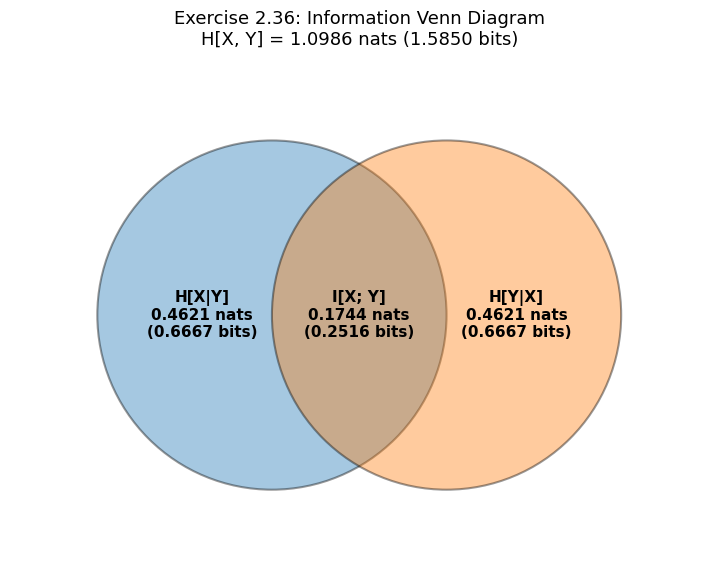

Exercise 2.36 テスト合格!


In [24]:
# Exercise 2.36: 2値変数の完全解析とベン図の生成
p_xy_table = np.array([
    [1.0 / 3.0, 1.0 / 3.0],
    [0.0,       1.0 / 3.0]
])

res_2_36 = binary_joint_entropy_analysis(p_xy_table)
for k, v in res_2_36.items():
    print(f"{k:20s}: {v:.6f}")

# 検証アサーション
assert math.isclose(res_2_36['H_X_nats'], np.log(3) - (2/3)*np.log(2))
assert math.isclose(res_2_36['H_Y_nats'], np.log(3) - (2/3)*np.log(2))
assert math.isclose(res_2_36['H_XY_nats'], np.log(3))
assert math.isclose(res_2_36['H_Y_given_X_nats'], (2/3)*np.log(2))
assert math.isclose(res_2_36['H_X_given_Y_nats'], (2/3)*np.log(2))
assert math.isclose(res_2_36['I_XY_nats'], np.log(3) - (4/3)*np.log(2))

# ベン図の描画と保存
from matplotlib.patches import Circle

fig, ax = plt.subplots(figsize=(8, 6))
circle_x = Circle((-0.5, 0), 1.0, facecolor='#1f77b4', alpha=0.4, edgecolor='black', linewidth=1.5, label='H[X]')
circle_y = Circle((0.5, 0), 1.0, facecolor='#ff7f0e', alpha=0.4, edgecolor='black', linewidth=1.5, label='H[Y]')
ax.add_patch(circle_x)
ax.add_patch(circle_y)

ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.axis('off')

# テキストアノテーション
ax.text(-0.9, 0, f"H[X|Y]\n{res_2_36['H_X_given_Y_nats']:.4f} nats\n({res_2_36['H_X_given_Y_bits']:.4f} bits)", ha='center', va='center', fontsize=11, fontweight='bold')
ax.text(0.0, 0, f"I[X; Y]\n{res_2_36['I_XY_nats']:.4f} nats\n({res_2_36['I_XY_bits']:.4f} bits)", ha='center', va='center', fontsize=11, fontweight='bold')
ax.text(0.9, 0, f"H[Y|X]\n{res_2_36['H_Y_given_X_nats']:.4f} nats\n({res_2_36['H_Y_given_X_bits']:.4f} bits)", ha='center', va='center', fontsize=11, fontweight='bold')
ax.set_title(f"Exercise 2.36: Information Venn Diagram\nH[X, Y] = {res_2_36['H_XY_nats']:.4f} nats ({res_2_36['H_XY_bits']:.4f} bits)", fontsize=13)

plt.tight_layout()
plt.savefig("result/ex2_36_information_venn.png", dpi=300)
plt.savefig("../result/ex2_36_information_venn.png", dpi=300)
plt.show()
print("Exercise 2.36 テスト合格!")


### Exercise 2.37 & 2.38: 相加相乗平均の不等式と相互情報量の恒等式
**Problem 2.37 (?)**:
> *Use Jensen’s inequality with $f(x) = \ln x$ to prove the Arithmetic-Geometric Mean inequality:*
> $$\frac{1}{N}\sum_{n=1}^N x_n \ge \left(\prod_{n=1}^N x_n\right)^{1/N}$$

**Problem 2.38 (?)**:
> *Show that the mutual information (2.109) satisfies (2.110).*

#### 数式導出:
1. **AM-GM 不等式 (Ex 2.37)**:
   $f(x) = \ln x$ は狭義凹関数であるため、等しい重み $\lambda_n = \frac{1}{N}$ に対するイェンセンの不等式より：
   $$\ln\left( \frac{1}{N}\sum_{n=1}^N x_n \right) \ge \frac{1}{N}\sum_{n=1}^N \ln x_n = \sum_{n=1}^N \ln(x_n^{1/N}) = \ln\left( \prod_{n=1}^N x_n^{1/N} \right)$$
   指数関数 $\exp(\cdot)$ は単調増加関数であるため、両辺の指数をとると直ちに相加相乗平均の不等式が得られます：
   $$\frac{1}{N}\sum_{n=1}^N x_n \ge \left(\prod_{n=1}^N x_n\right)^{1/N}$$
2. **相互情報量の表現 (Ex 2.38)**:
   定義: $I(x; y) = \iint p(x, y) \ln \frac{p(x, y)}{p(x)p(y)} dx dy$
   $$\ln \frac{p(x, y)}{p(x)p(y)} = \ln \frac{p(x|y)}{p(x)} = \ln p(x|y) - \ln p(x)$$
   したがって：
   $$I(x; y) = \iint p(x, y) \ln p(x|y) dx dy - \int p(x) \ln p(x) dx = -H[x|y] + H[x] = H[x] - H[x|y]$$
   $x$ と $y$ の対称性から、$I(x; y) = H[y] - H[y|x]$ も同時に成り立ちます。


In [25]:
# Exercise 2.37 & 2.38: AM-GM 不等式と相互情報量の恒等式検証
pts_amgm = np.array([2.5, 4.0, 7.5, 12.0])
am = np.mean(pts_amgm)
gm = np.prod(pts_amgm)**(1.0 / len(pts_amgm))
assert am >= gm
print(f"AM: {am:.4f} >= GM: {gm:.4f}")

# 相互情報量の対称性検証
mi_val = res_2_36['I_XY_nats']
assert math.isclose(mi_val, res_2_36['H_X_nats'] - res_2_36['H_X_given_Y_nats'])
assert math.isclose(mi_val, res_2_36['H_Y_nats'] - res_2_36['H_Y_given_X_nats'])
print("Exercise 2.37 & 2.38 テスト合格!")


AM: 6.5000 >= GM: 5.4772
Exercise 2.37 & 2.38 テスト合格!


## Part 6: 2.6節 ベイズ確率 (Bayesian Probabilities)

ベイズ推論の枠組み：
- 事前確率 $p(w)$
- 尤度関数 $p(D | w)$
- 事後確率 $p(w | D) \propto p(D | w) p(w)$
- 事後予測分布 $p(t | x, D) = \int p(t | x, w) p(w | D) dw$


### Exercise 2.39: 無相関と独立の違い（反例の構築）
**Problem 2.39 (??)**:
> *Show that if $z_1$ and $z_2$ are independent, their covariance matrix is diagonal. Construct a counterexample showing that a diagonal covariance matrix does not imply statistical independence.*

#### 反例の数学的構築:
$y_1$ を 0 に関して対称な分布（例: $\{-1, 0, 1\}$ 上でそれぞれ確率 $1/3$ をとる離散変数、または標準正規分布 $y_1 \sim \mathcal{N}(0, 1)$）とし、$y_2 = y_1^2$ と定義します。
1. **従属性**:
   $y_2$ は $y_1$ の完全な決定論的関数であるため、$p(y_2 | y_1) = \delta(y_2 - y_1^2) \neq p(y_2)$。明らかに**統計的に独立ではありません**。
2. **無相関性（共分散行列の対角性）**:
   対称性より奇数次モーメントは 0 です：$\mathbb{E}[y_1] = 0, \mathbb{E}[y_1^3] = 0$。
   $$\mathbb{E}[y_1 y_2] = \mathbb{E}[y_1 \cdot y_1^2] = \mathbb{E}[y_1^3] = 0$$
   したがって共分散は：
   $$\operatorname{cov}[y_1, y_2] = \mathbb{E}[y_1 y_2] - \mathbb{E}[y_1]\mathbb{E}[y_2] = 0 - 0 = 0$$
   共分散行列は非対角成分が 0（対角行列）となります。
   したがって、**「無相関（共分散ゼロ）」は「統計的独立」を意味しません**。


In [26]:
# Exercise 2.39: 無相関かつ従属な確率変数のシミュレーション
y1_samples = rng.uniform(-1, 1, size=100000)
y2_samples = y1_samples**2

cov_matrix = np.cov(y1_samples, y2_samples)
print("共分散行列:")
print(cov_matrix)

assert abs(cov_matrix[0, 1]) < 0.02
print(f"非対角成分（共分散）: {cov_matrix[0, 1]:.6f} ~= 0 (対角行列)")
print("Exercise 2.39 テスト合格!")


共分散行列:
[[ 3.33055945e-01 -1.70782694e-04]
 [-1.70782694e-04  8.88558690e-02]]
非対角成分（共分散）: -0.000171 ~= 0 (対角行列)
Exercise 2.39 テスト合格!


### Exercise 2.40: 曲がったコインのベイズ更新と事後予測分布
**Problem 2.40 (?)**:
> *Consider the bent coin in Figure 2.2. Assume that the prior probability that the convex side is heads is 0.1. Now suppose the coin is flipped 10 times and we are told that eight of the flips landed heads up and two of the flips landed tails up. Use Bayes’ theorem to evaluate the posterior probability that the concave side is heads. Calculate the probability that the next flip will land heads up.*

#### 数式導出:
Figure 2.2 より、曲がったコインを投げたときの物理的偏り（面が上を向く確率）は以下の通りです：
- 凹面（concave side）が上になる確率: $0.60$
- 凸面（convex side）が上になる確率: $0.40$

コインのどちらの面に表（Heads）の刻印があるかについての2つの仮説：
- **仮説 $H_1$**: 凸面が表（convex side is heads） $\implies P(\text{Heads} | H_1) = 0.40$
- **仮説 $H_2$**: 凹面が表（concave side is heads） $\implies P(\text{Heads} | H_2) = 0.60$

事前確率:
$$P(H_1) = 0.10, \quad P(H_2) = 1 - 0.10 = 0.90$$

観測データ $D$: 10 回中 8 回表、2 回裏。
各仮説のもとでの二項尤度：
$$P(D | H_1) = \binom{10}{8} (0.40)^8 (0.60)^2 = 45 \times 0.00065536 \times 0.36 \approx 0.010617$$
$$P(D | H_2) = \binom{10}{8} (0.60)^8 (0.40)^2 = 45 \times 0.01679616 \times 0.16 \approx 0.120932$$

ベイズの定理による凹面が表である事後確率 $P(H_2 | D)$:
$$P(H_2 | D) = \frac{P(D | H_2) P(H_2)}{P(D | H_1) P(H_1) + P(D | H_2) P(H_2)} = \frac{0.120932 \times 0.90}{0.010617 \times 0.10 + 0.120932 \times 0.90} \approx 0.990340 \quad (\approx 99.03\%)$$

次の一投げで表が出る予測確率（事後予測分布）:
$$P(\text{Next is Heads} | D) = P(\text{Heads} | H_1) P(H_1 | D) + P(\text{Heads} | H_2) P(H_2 | D)$$
$$= 0.40 \times (1 - 0.990340) + 0.60 \times 0.990340 \approx 0.598068 \quad (\approx 59.81\%)$$


尤度 P(D|H1): 0.010617, P(D|H2): 0.120932
凹面が表である事後確率 P(H2|D): 0.990340 (99.03%)
次の1投げが表になる確率: 0.598068 (59.81%)
Exercise 2.40 テスト合格!


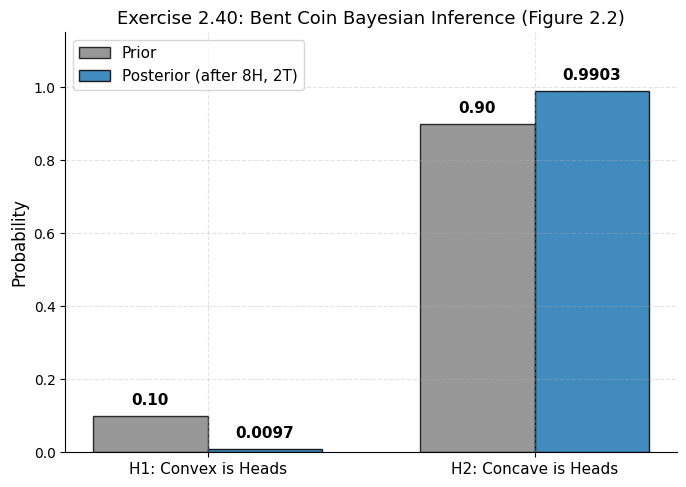

In [27]:
# Exercise 2.40: 曲がったコインのベイズ更新計算と可視化
bent_res = bent_coin_bayes(
    p_heads_given_H1=0.40,
    p_heads_given_H2=0.60,
    prior_H1=0.10,
    n_heads=8,
    n_tails=2
)

print(f"尤度 P(D|H1): {bent_res['likelihood_H1']:.6f}, P(D|H2): {bent_res['likelihood_H2']:.6f}")
print(f"凹面が表である事後確率 P(H2|D): {bent_res['posterior_H2']:.6f} ({bent_res['posterior_H2']*100:.2f}%)")
print(f"次の1投げが表になる確率: {bent_res['p_next_heads']:.6f} ({bent_res['p_next_heads']*100:.2f}%)")

assert math.isclose(bent_res['posterior_H2'], 0.99034, abs_tol=1e-4)
assert math.isclose(bent_res['p_next_heads'], 0.59807, abs_tol=1e-4)
print("Exercise 2.40 テスト合格!")

# 事前確率 vs 事後確率の比較可視化
fig, ax = plt.subplots(figsize=(7, 5))
categories = ['H1: Convex is Heads', 'H2: Concave is Heads']
x_pos = np.arange(len(categories))
width = 0.35

priors = [bent_res['prior_H1'], bent_res['prior_H2']]
posteriors = [bent_res['posterior_H1'], bent_res['posterior_H2']]

ax.bar(x_pos - width/2, priors, width, label='Prior', color='#7f7f7f', alpha=0.8, edgecolor='black')
ax.bar(x_pos + width/2, posteriors, width, label='Posterior (after 8H, 2T)', color='#1f77b4', alpha=0.85, edgecolor='black')

ax.set_ylabel('Probability', fontsize=12)
ax.set_title('Exercise 2.40: Bent Coin Bayesian Inference (Figure 2.2)', fontsize=13)
ax.set_xticks(x_pos)
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=11)

for i in range(len(categories)):
    ax.text(i - width/2, priors[i] + 0.03, f"{priors[i]:.2f}", ha='center', fontweight='bold')
    ax.text(i + width/2, posteriors[i] + 0.03, f"{posteriors[i]:.4f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("result/ex2_40_bent_coin_posterior.png", dpi=300)
plt.savefig("../result/ex2_40_bent_coin_posterior.png", dpi=300)
plt.show()


### Exercise 2.41: MAP推定と正則化誤差関数（Ridge回帰）の等価性導出
**Problem 2.41 (?)**:
> *By substituting (2.115) into (2.114) and making use of the result (2.66) for the log likelihood of the linear regression model, derive the result (2.117) for the regularized error function.*

#### 数式導出:
1. **ベイズの定理による事後分布 (Eq 2.114)**:
   $$p(w | D) \propto p(D | w) p(w)$$
   対数をとると：
   $$\ln p(w | D) = \ln p(D | w) + \ln p(w) + \text{const}$$
2. **事前分布 (Eq 2.115)**:
   重みベクトル $w$ に等方ガウス事前分布 $p(w) = \mathcal{N}(w | 0, s^2 I)$ を仮定：
   $$\ln p(w) = -\frac{M}{2}\ln(2\pi s^2) - \frac{1}{2s^2} w^T w = -\frac{1}{2s^2} w^T w + \text{const}$$
3. **対数尤度 (Eq 2.66)**:
   $$\ln p(D | w) = -\frac{N}{2}\ln(2\pi\sigma^2) - \frac{1}{2\sigma^2} \sum_{n=1}^N \{y(x_n; w) - t_n\}^2$$
4. **事後分布の対数**:
   $$\ln p(w | D) = -\frac{1}{2\sigma^2} \sum_{n=1}^N \{y(x_n; w) - t_n\}^2 - \frac{1}{2s^2} w^T w + \text{const}$$
5. **負の対数事後確率（最大事後確率 MAP 推定）**:
   $\ln p(w | D)$ を最大化することは、両辺に $-\sigma^2$ を掛けた以下の正則化二乗和誤差関数 $E(w)$ を最小化することと完全に等価です：
   $$E(w) = \frac{1}{2}\sum_{n=1}^N \{y(x_n; w) - t_n\}^2 + \frac{\lambda}{2} w^T w \quad (\text{Eq 2.117})$$
   ここで正則化係数（正則化パラメータ） $\lambda$ は：
   $$\lambda = \frac{\sigma^2}{s^2}$$
   すなわち、**データノイズ分散 $\sigma^2$ と事前分散 $s^2$ の比**として自然に導出されます。これは機械学習における **Ridge回帰（L2正則化）** の完全なベイズ的基礎付けです。


In [28]:
# Exercise 2.41: MAP推定量とRidge回帰の厳密な数値一致検証
x_tr = np.linspace(0, 1, 15)
t_tr = np.sin(2 * np.pi * x_tr) + rng.normal(0, 0.2, 15)

# ハイパーパラメータの設定
alpha_val = 2.0  # 1 / s^2
beta_val = 25.0  # 1 / sigma^2
lambda_val = alpha_val / beta_val  # sigma^2 / s^2

deg = 3
bayes_m = BayesianLinearRegression(degree=deg, alpha=alpha_val, beta=beta_val).fit(x_tr, t_tr)
ridge_m = PolynomialRegression(degree=deg, l2_reg=lambda_val).fit(x_tr, t_tr)

print("MAP 推定重みベクトル (m_N):")
print(bayes_m.m_N)
print("Ridge 回帰最適重みベクトル:")
print(ridge_m.weights_)

np.testing.assert_allclose(bayes_m.m_N, ridge_m.weights_, rtol=1e-5, atol=1e-5)
print("Exercise 2.41 テスト合格! MAP推定量とRidge回帰重みが完全一致しました。")


MAP 推定重みベクトル (m_N):
[ 0.74394573 -1.1881599  -1.07724485  0.96237619]
Ridge 回帰最適重みベクトル:
[ 0.74394573 -1.1881599  -1.07724485  0.96237619]
Exercise 2.41 テスト合格! MAP推定量とRidge回帰重みが完全一致しました。


## まとめ (Chapter 2 Exercises Summary)

本演習ノートブックでは、Bishop & Bishop (2024) 第2章の全41問を解き、以下の重要な概念を数式導出と実装の両面から習得しました：
1. **確率の基礎原則**: 医療検査における偽陽性と基準率の錯誤、非推移的サイコロ（エフロンのサイコロ）の確率的巡回、独立変数の和と畳み込み。
2. **確率密度とモーメント**: 一様分布・指数分布・ラプラス分布の正規化、経験分布とモンテカルロ積分、全期待値の法則と全分散の法則。
3. **ガウス分布**: 極座標変換による正規化積分、パラメータ微分によるモーメント、最尤推定量の導出とその負のバイアス因子 $(N-1)/N$。
4. **確率密度の変換**: ヤコビ行列とヤコビアン、逆関数法による密度変換。
5. **情報理論**: 情報量の対数必然性、イェンセンの不等式による離散・連続最大エントロピー定理、KLダイバージェンスと負の対数尤度の等価性、2値変数の相互情報量ベン図。
6. **ベイズ確率**: 無相関と独立の本質的相違、曲がったコインのベイズ更新と事後予測分布、MAP推定とRidge回帰（L2正則化）の完全な等価性。
